In [1]:

import os, sys, importlib, pathlib
import pandas as pd
from pathlib import Path
sys.path.append (os.path.abspath(".."))

import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import statsmodels.api as sm
import statsmodels.formula.api as smf
# my utils
from utils import desc_new_old

def p_to_sig(p):
    if p < 0.001: return '***'
    elif p < 0.01: return '**'
    elif p < 0.05: return '*'
    elif p < 0.1: return '.'
    else: return ''


## data

In [2]:
path_df=r"../data_processed\listings_tactics_bio_vis-paris_london-2306_2312_2406.csv"
df_all=pd.read_csv(path_df)
print(df_all.shape)

C:\Users\yeliu\AppData\Local\Temp\ipykernel_1912\4181052062.py:2: DtypeWarning: Columns (6,68,115) have mixed types. Specify dtype option on import or set low_memory=False.
  df_all=pd.read_csv(path_df)


(266852, 125)


In [4]:
# time str
df_all['time']=df_all['time'].astype(str)
print(df_all.time.dtype)
print(df_all.time.unique())


## fillna
tactics_bio = [
    "ouverture",
    "authenticité",
    "sociabilité",
    "auto_promotion",
    "exemplarité",
]
tactics_pic=['host_picture_type']# no_person, pro_style, life_style

df_all[tactics_bio]=df_all[tactics_bio].fillna(0)
df_all["host_picture_type"]=df_all["host_picture_type"].fillna("no_person")


# dummies for host_picture_type
df=df_all.copy()
df_all['is_portrait']=df_all["host_picture_type"].apply(lambda x : 1 if x=="pro_style" else 0)
df_all['is_lifestyle']=df_all["host_picture_type"].apply(lambda x : 1 if x=="life_style" else 0)
df_all['no_person']=df_all["host_picture_type"].apply(lambda x : 1 if x=="no_person" else 0)

tactics_pic_dummies=['is_portrait','is_lifestyle','no_person']
print(df_all[tactics_pic_dummies].value_counts(dropna=False))


# time x is_paris
print(df_all[['time','in_paris']].value_counts(dropna=False))
 

object
['2306' '2312' '2406']
is_portrait  is_lifestyle  no_person
1            0             0            94648
0            0             1            91235
             1             0            80969
Name: count, dtype: int64
time  in_paris
2406  1           62738
      0           49856
2312  0           43172
2306  0           42356
2312  1           35829
2306  1           32901
Name: count, dtype: int64


In [5]:
# is_new_host
host_2306 = df_all[df_all['time'] == "2306"]['host_id'].to_list()
host_2312 = df_all[df_all['time'] == "2312"]['host_id'].to_list()


df_all['is_new_host'] = 0  # 先初始化

# 2312 vs 2306
mask_2312 = df_all['time'] == "2312"
df_all.loc[mask_2312, 'is_new_host'] = (
    ~df_all.loc[mask_2312, 'host_id'].isin(host_2306)
).astype(int)

# 2406 vs 2312
mask_2406 = df_all['time'] == "2406"
df_all.loc[mask_2406, 'is_new_host'] = (
    ~df_all.loc[mask_2406, 'host_id'].isin(host_2312)
).astype(int)

display(df_all.groupby(["time",'in_paris'])['is_new_host'].value_counts().reset_index())

,time,in_paris,is_new_host,count
0,2306,0,0,42356
1,2306,1,0,32901
2,2312,0,0,32360
3,2312,0,1,10812
4,2312,1,0,24780
5,2312,1,1,11049
6,2406,0,0,37937
7,2406,0,1,11919
8,2406,1,0,34176
9,2406,1,1,28562


In [6]:
# ---colors----
blue_cmap = plt.cm.Blues
orange_cmap = plt.cm.Oranges
n = 2 # ==len(hue) 每组柱子的数量
london_colors = blue_cmap(np.linspace(0.3, 0.8, n))
paris_colors  = orange_cmap(np.linspace(0.3, 0.8, n))
colors = (
    list(london_colors) +
    list(paris_colors)
)

# global

In [7]:
df=df_all.copy()
agg=df.groupby(['in_paris','time'])[tactics_bio+tactics_pic_dummies].mean().reset_index()
agg_long=agg.melt(
    id_vars=['in_paris', 'time'],
    value_vars=tactics_bio+tactics_pic_dummies,
    var_name='variable',
    value_name='mean'
)
agg_long['group']=agg_long.apply(lambda row: f"{'Paris' if row['in_paris']==1 else 'Londres'} {row['time']}", axis=1)
agg_long

,in_paris,time,variable,mean,group
0,0,2306,ouverture,-0.111349,Londres 2306
1,0,2312,ouverture,-0.111726,Londres 2312
2,0,2406,ouverture,-0.113564,Londres 2406
3,1,2306,ouverture,-0.093083,Paris 2306
4,1,2312,ouverture,-0.083193,Paris 2312
5,1,2406,ouverture,-0.088205,Paris 2406
6,0,2306,authenticité,-0.181066,Londres 2306
7,0,2312,authenticité,-0.204839,Londres 2312
8,0,2406,authenticité,-0.216109,Londres 2406
9,1,2306,authenticité,-0.158274,Paris 2306


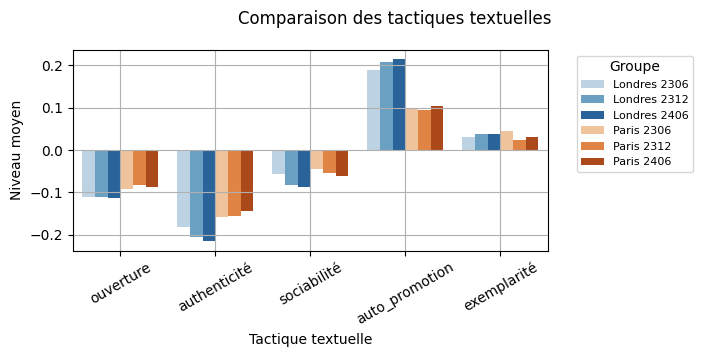

In [8]:
tactics=tactics_bio
df_plot=agg_long[agg_long['variable'].isin(tactics)].copy()
groups=df_plot['group'].unique()

# ---colors----
blue_cmap = plt.cm.Blues
orange_cmap = plt.cm.Oranges
n = 3  # 每组数量
london_colors = blue_cmap(np.linspace(0.3, 0.8, n))
paris_colors  = orange_cmap(np.linspace(0.3, 0.8, n))

colors = (
    list(london_colors) +
    list(paris_colors)
)
palette={k: v for k, v in zip (groups, colors)}


# vis
fig, ax=plt.subplots(figsize=(8,4))

sns.barplot(
    data=df_plot,   
    x="variable",
    y="mean",
    hue="group",
    palette=palette,
    order=tactics_bio,#***
    # errorbar="sd"
    ax=ax
)
ax.tick_params(axis="x", rotation=30)
ax.set_ylabel("Niveau moyen")
ax.set_xlabel("Tactique textuelle")
ax.grid()

plt.suptitle("Comparaison des tactiques textuelles",fontsize=12)

handles, labels=ax.get_legend_handles_labels()
plt.legend(handles, labels, title="Groupe", loc="upper left", bbox_to_anchor=(1.05, 1), fontsize=8)
plt.tight_layout(rect=[0,0.1, 0.9,1])

plt.show()
# 整体而言，paris更注重ouv，authen，socio，london的auto更高，exem两者相似



C:\Users\yeliu\AppData\Local\Temp\ipykernel_32028\1811378941.py:38: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(


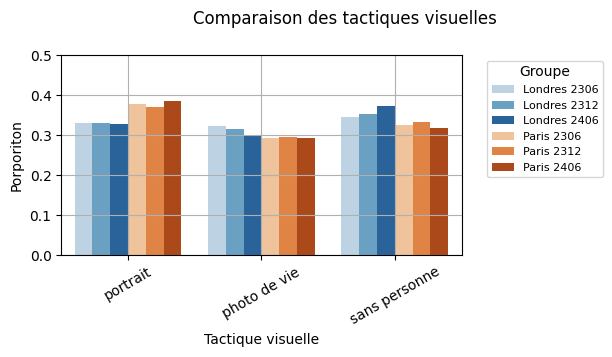

In [9]:
tactics=tactics_pic_dummies
label_map={'is_portrait':"portrait",
           'is_lifestyle':'photo de vie',
           "no_person":"sans personne"}

df_plot=agg_long[agg_long['variable'].isin(tactics)].copy()
groups=df_plot['group'].unique()

# ---colors----
blue_cmap = plt.cm.Blues
orange_cmap = plt.cm.Oranges
n = 3  # 每组数量
london_colors = blue_cmap(np.linspace(0.3, 0.8, n))
paris_colors  = orange_cmap(np.linspace(0.3, 0.8, n))

colors = (
    list(london_colors) +
    list(paris_colors)
)
palette={k: v for k, v in zip (groups, colors)}


# vis
fig, ax=plt.subplots(figsize=(7,4))

sns.barplot(
    data=df_plot,   
    x="variable",
    y="mean",
    hue="group",
    palette=palette,
    order=tactics,#***
    # errorbar="sd"
    ax=ax
)

ax.set_ylim(0, 0.5)
ax.set_xticklabels(
    [label_map[x.get_text()] for x in ax.get_xticklabels()],
    rotation=30
)
# ax.set_xticklabels([label_map[x.get_text()] for x in ax.get_xticklabels],rotation=30)
ax.tick_params(axis="x", rotation=30)
ax.set_ylabel("Porporiton")
ax.set_xlabel("Tactique visuelle")
ax.grid()

plt.suptitle("Comparaison des tactiques visuelles",fontsize=12)

handles, labels=ax.get_legend_handles_labels()

plt.legend(handles, labels, title="Groupe", loc="upper left", bbox_to_anchor=(1.05, 1), fontsize=8)
plt.tight_layout(rect=[0,0.1, 0.9,1])

plt.show()
# 整体而言，paris更注重ouv，authen，socio，london的auto更高，exem两者相似



In [6]:
var='auto_promotion'
df=df_all.copy()

formula= (f"{var} ~ C(host_identity_verified)  + review_scores_rating + has_rating +"
            "number_of_reviews_ltm + "
            "C(host_is_superhost) +"
            "years_since_host + professional_host + "
            "host_response_rate +  C(host_response_time)+"
            "has_text + lang_en + lang_fr + text_length+"
            "price  + availability_90 + C(room_type) + C(instant_bookable) + "
            "C(time) + in_paris * C(time)"
    )
model_tactic=smf.ols(formula, data=df).fit()
print(model_tactic.summary())


                            OLS Regression Results                            
Dep. Variable:         auto_promotion   R-squared:                       0.267
Model:                            OLS   Adj. R-squared:                  0.267
Method:                 Least Squares   F-statistic:                     3604.
Date:                Tue, 21 Apr 2026   Prob (F-statistic):               0.00
Time:                        15:03:44   Log-Likelihood:            -2.4809e+05
No. Observations:              266852   AIC:                         4.962e+05
Df Residuals:                  266824   BIC:                         4.965e+05
Df Model:                          27                                         
Covariance Type:            nonrobust                                         
                                                  coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------------------

In [ ]:
## post did

specs=[
    # constants: time=2312-2406, in_paris: paris-london, 
    # is_new_host, terms 
    # (1, """
    #     in_paris:C(time)[T.2406]:is_new_host
    #     - in_paris:C(time)[T.2312]:is_new_host
    #     - C(time)[T.2406]:is_new_host
    #     + C(time)[T.2312]:is_new_host
    #     """), 
    # 在新老房东对比中，2312作为了基准组，
    
    """    
    in_paris:C(time)[T.2406]
    -in_paris:C(time)[T.2312]
    - C(time)[T.2406] 
    + C(time)[T.2312] 
    """
    ## post did: Δ Paris 在 2312→2406 的变化 − London 在同一时期的变化
    ## JO effect+ddd in time（diff of paris-london in 2406, -diff 2312 (pretrend))
    ## ddd 则不需要再减去 - (C(time)[T.2406] - C(time)[T.2312])!时间效应已经被控制了？
    
]

df=df_all.copy()
results=[]
for var in tactics_bio+tactics_pic_dummies:
    formula= (f"{var} ~ C(host_identity_verified)  + review_scores_rating + has_rating +"
                "number_of_reviews_ltm + "
                "C(host_is_superhost) +"
                "years_since_host + professional_host + "
                "host_response_rate +  C(host_response_time)+"
                "has_text + lang_en + lang_fr + text_length+"
                "price  + availability_90 + C(room_type) + C(instant_bookable) + "
                "C(time) + in_paris * C(time)"
        )
    model_tactic=smf.ols(formula, data=df).fit()

    for i, term in enumerate(specs):
        test = model_tactic.t_test(term)
        sig=p_to_sig(test.pvalue)
        res= pd.DataFrame({
            'variable':var,
            "coef": test.effect[0],
            "se": test.sd[0],
            "pval": test.pvalue,
            "sig":sig,
            "ci_low": test.conf_int()[0][0],
            "ci_high": test.conf_int()[0][1],
            'label':f"{var}{sig}"
        })
        results.append(res)

results_post_did=pd.concat(results, axis=0)
display(results_post_did)
# 以前的那个图是在每一个时间点上的差，现在的这个还减去了时间2406-2312的差异!

,variable,coef,se,pval,sig,ci_low,ci_high,label
0,ouverture,-0.003929,0.009298,6.726216e-01,,-0.022153,0.014295,ouverture
0,authenticité,0.023845,0.009631,1.329529e-02,*,0.004968,0.042723,authenticité*
0,sociabilité,0.022006,0.009954,2.704422e-02,*,0.002498,0.041515,sociabilité*
0,auto_promotion,0.025596,0.009074,4.792441e-03,**,0.007811,0.043382,auto_promotion**
0,exemplarité,0.033232,0.009641,5.670961e-04,***,0.014336,0.052129,exemplarité***
0,is_portrait,0.017005,0.006841,1.292948e-02,*,0.003597,0.030414,is_portrait*
0,is_lifestyle,0.027812,0.006626,2.703338e-05,***,0.014824,0.040799,is_lifestyle***
0,no_person,-0.044817,0.006206,5.158131e-13,***,-0.056981,-0.032653,no_person***


In [ ]:
## pre did
specs=[
    # constants: time=2312-2406, in_paris: paris-london, 
    # is_new_host, terms 
    # (1, """
    #     in_paris:C(time)[T.2406]:is_new_host
    #     - in_paris:C(time)[T.2312]:is_new_host
    #     - C(time)[T.2406]:is_new_host
    #     + C(time)[T.2312]:is_new_host
    #     """), 
    # 在新老房东对比中，2312作为了基准组，
    
    """    
    in_paris:C(time)[T.2312]
    """
    # pre did ​
    
]

df=df_all.copy()
results=[]
for var in tactics_bio+tactics_pic_dummies:
    formula= (f"{var} ~ C(host_identity_verified)  + review_scores_rating + has_rating +"
                "number_of_reviews_ltm + "
                "C(host_is_superhost) +"
                "years_since_host + professional_host + "
                "host_response_rate +  C(host_response_time)+"
                "has_text + lang_en + lang_fr + text_length+"
                "price  + availability_90 + C(room_type) + C(instant_bookable) + "
                "C(time) + in_paris * C(time)"
        )
    model_tactic=smf.ols(formula, data=df).fit()

    for i, term in enumerate(specs):
        test = model_tactic.t_test(term)
        sig=p_to_sig(test.pvalue)
        res= pd.DataFrame({
            'variable':var,
            "coef": test.effect[0],
            "se": test.sd[0],
            "pval": test.pvalue,
            "sig":sig,
            "ci_low": test.conf_int()[0][0],
            "ci_high": test.conf_int()[0][1],
            'label':f"{var}{sig}"
        })
        results.append(res)

results_pre_did=pd.concat(results, axis=0)
display(results_pre_did)


,variable,coef,se,pval,sig,ci_low,ci_high,label
0,ouverture,0.005668,0.006452,0.379627,,-0.006977,0.018313,ouverture
0,authenticité,0.029654,0.006683,0.000009,***,0.016556,0.042753,authenticité***
0,sociabilité,0.022324,0.006906,0.001228,**,0.008787,0.035860,sociabilité**
0,auto_promotion,-0.014188,0.006296,0.024241,*,-0.026529,-0.001847,auto_promotion*
0,exemplarité,-0.020017,0.006690,0.002770,**,-0.033128,-0.006905,exemplarité**
0,is_portrait,-0.006704,0.004747,0.157896,,-0.016007,0.002600,is_portrait
0,is_lifestyle,0.008325,0.004598,0.070185,.,-0.000686,0.017337,is_lifestyle.
0,no_person,-0.001622,0.004306,0.706482,,-0.010062,0.006818,no_person


In [342]:
## ddd
specs=[
    # constants: time=2312-2406, in_paris: paris-london, 
    # is_new_host, terms 
    # (1, """
    #     in_paris:C(time)[T.2406]:is_new_host
    #     - in_paris:C(time)[T.2312]:is_new_host
    #     - C(time)[T.2406]:is_new_host
    #     + C(time)[T.2312]:is_new_host
    #     """), 
    # 在新老房东对比中，2312作为了基准组，
    
    """    
    in_paris:C(time)[T.2406]
    -in_paris:C(time)[T.2312]  
    """
    #in_paris:C(2406)
    # = “2406 时 Paris 相对 London 的 gap（已经扣掉共同时间变化）”
    # ✔ in_paris:C(2312)
    # = “2312 时 Paris 相对 London 的 gap（已经扣掉共同时间变化）”
    
    ## paris相比于london的差异(did/gap),从2312到2406的变化(ddd) 
    
]

df=df_all.copy()
results=[]
var_map={
    'is_portrait':"portrait",
    "is_lifestyle":'photo de vie',
    "no_person":'sans personne'
}

for var in tactics_bio+tactics_pic_dummies:
    formula= (f"{var} ~ C(host_identity_verified)  + review_scores_rating + has_rating +"
                "number_of_reviews_ltm + "
                "C(host_is_superhost) +"
                "years_since_host + professional_host + "
                "host_response_rate +  C(host_response_time)+"
                "has_text + lang_en + lang_fr + text_length+"
                "price  + availability_90 + C(room_type) + C(instant_bookable) + "
                "C(time) + in_paris * C(time)"
        )
    model_tactic=smf.ols(formula, data=df).fit()

    for i, term in enumerate(specs):
        test = model_tactic.t_test(term)
        sig=p_to_sig(test.pvalue)
        res= pd.DataFrame({
            'variable':var,
            "coef": test.effect[0],
            "se": test.sd[0],
            "pval": test.pvalue,
            "sig":sig,
            "ci_low": test.conf_int()[0][0],
            "ci_high": test.conf_int()[0][1],
            'label':f"{var_map.get(var,'') if var in var_map else var} {sig}"
        })
        results.append(res)

results_ddd_all=pd.concat(results, axis=0)
display(results_ddd_all)
### paris比london在2406的gap，减去它们在2312的gap（pretrend），比较gap变化
# 如果有冲击，会有显著变化gap change

,variable,coef,se,pval,sig,ci_low,ci_high,label
0,ouverture,-0.003955,0.005895,5.022069e-01,,-0.015509,0.007598,ouverture
0,authenticité,0.014043,0.006106,2.145399e-02,*,0.002076,0.026011,authenticité *
0,sociabilité,0.012459,0.006310,4.832976e-02,*,0.000091,0.024827,sociabilité *
0,auto_promotion,0.028564,0.005753,6.870991e-07,***,0.017288,0.039839,auto_promotion ***
0,exemplarité,0.024492,0.006112,6.149051e-05,***,0.012512,0.036471,exemplarité ***
0,is_portrait,0.017154,0.004337,7.652006e-05,***,0.008653,0.025654,portrait ***
0,is_lifestyle,0.014838,0.004201,4.121373e-04,***,0.006605,0.023072,photo de vie ***
0,no_person,-0.031992,0.003934,4.268024e-16,***,-0.039703,-0.024280,sans personne ***


,variable,coef,se,pval,sig,ci_low,ci_high,label
0,exemplarité,0.024492,0.006112,6.149051e-05,***,0.012512,0.036471,exemplarité ***
1,auto_promotion,0.028564,0.005753,6.870991e-07,***,0.017288,0.039839,auto_promotion ***
2,sociabilité,0.012459,0.006310,4.832976e-02,*,0.000091,0.024827,sociabilité *
3,authenticité,0.014043,0.006106,2.145399e-02,*,0.002076,0.026011,authenticité *
4,ouverture,-0.003955,0.005895,5.022069e-01,,-0.015509,0.007598,ouverture


,variable,coef,se,pval,sig,ci_low,ci_high,label
0,no_person,-0.031992,0.003934,4.268024e-16,***,-0.039703,-0.024280,sans personne ***
1,is_lifestyle,0.014838,0.004201,4.121373e-04,***,0.006605,0.023072,photo de vie ***
2,is_portrait,0.017154,0.004337,7.652006e-05,***,0.008653,0.025654,portrait ***


C:\Users\yeliu\AppData\Local\Temp\ipykernel_18128\3456683380.py:89: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0.1, 1, 1])# [left, bottom, right, top]


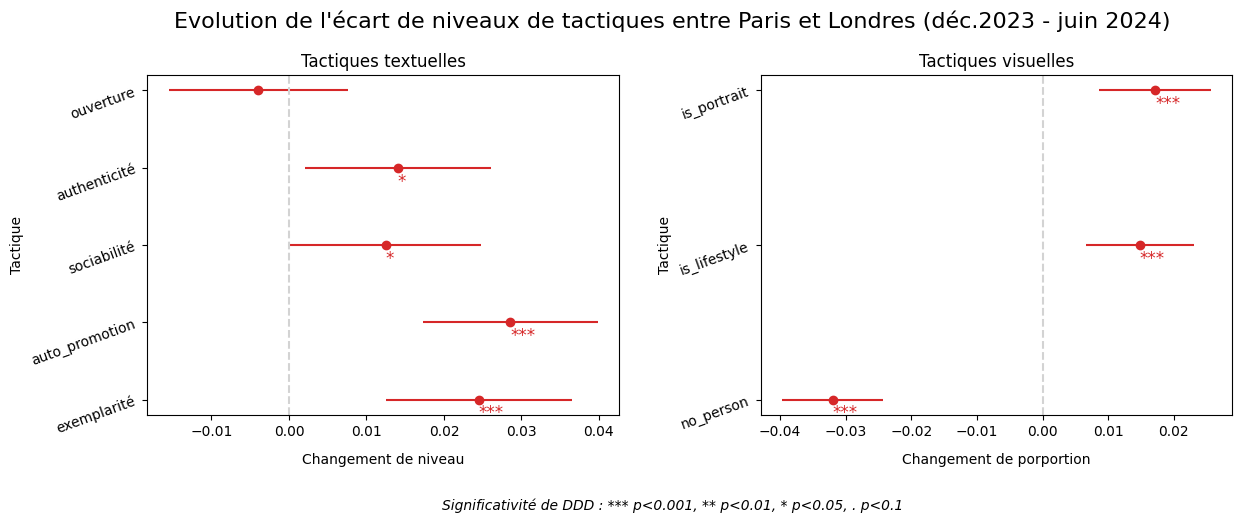

In [344]:
# ---colors----
blue_cmap = plt.cm.Blues
orange_cmap = plt.cm.Oranges
n = 2 # 每组柱子的数量
london_colors = blue_cmap(np.linspace(0.3, 0.8, n))
paris_colors  = orange_cmap(np.linspace(0.5, 0.8, n))

## ---layout 2facets----
import matplotlib.gridspec as gridspec
fig = plt.figure(figsize=(14, 5)) 
gs = gridspec.GridSpec(1, 2, figure=fig, hspace=0.5, wspace=0.3)# 1行2列

axes = []
# 第一行两个：分别占两列宽 (0:2, 2:4, 4:6)
ax1 = fig.add_subplot(gs[0, 0:1])
ax2 = fig.add_subplot(gs[0, 1:2])#**
axes.extend([ax1, ax2])


#
df_plot=results_ddd_all.copy()
color_change="tab:red"


for i, tactics in enumerate([tactics_bio, tactics_pic_dummies]):
    sub=df_plot[df_plot['variable'].isin(tactics)].copy()

    order = tactics[::-1]
    sub = sub.set_index("variable").loc[order].reset_index()    
    ax=axes[i]
    
    # #规定顺序：
    # sub['variable']=pd.Categorical(
    #     sub['variable'],
    #     categories=tactics[::-1],
    #     ordered=True
    # )    
    
    display(sub)# 5/3

    ax.errorbar(
        x=sub["coef"],
        y=sub["variable"],
        xerr=[sub["coef"] - sub["ci_low"], sub["ci_high"] - sub["coef"]],
        fmt='o', 
        # order = tactics[::-1],
        color=color_change
    )
    # ---sig---
    for _, row in sub.iterrows():
        ax.annotate(
            row["sig"],
            xy=(row["coef"], row["variable"]),
            xytext=(0, -10), 
            textcoords='offset points',
            ha='left',
            va='center',
            fontsize=12,
            color=color_change
    )    
            
    ax.axvline(0, linestyle='--', color="lightgray", label="Changement de Londres")    
    ax.set_xlabel(f"{'Changement de niveau' if i==0 else 'Changement de porportion'}", labelpad=10)
    ax.set_ylabel('Tactique')
    ax.tick_params(axis='y', rotation=20)
    ax.set_title(f"{'Tactiques textuelles' if i==0 else 'Tactiques visuelles'}")

# ax.legend(loc="upper left", bbox_to_anchor=(1.02, 1), borderaxespad=0)


# ## ---legend 2facets----
fig.suptitle(
    # "Différence des différences des"
    "Evolution de l'écart de niveaux de tactiques entre Paris et Londres (déc.2023 - juin 2024)", 
    fontsize=16,
    y=1.01
)
# (Paris−London)2406​−(Paris−London)2312​!!!!!
# ddd=did2406-did2312,在变化中再减去pre-trend


plt.figtext(
    0.5, 0.01,
    "Significativité de DDD : *** p<0.001, ** p<0.01, * p<0.05, . p<0.1",
    ha="center",
    fontsize=10,
    style="italic",   
)
plt.tight_layout(rect=[0, 0.1, 1, 1])# [left, bottom, right, top]
plt.subplots_adjust(bottom=0.2)#控制子图到底的距离，给text留出空间
plt.show()

# ==paris从2306到2406的变化减去自然变化（london）==jo带来的额外变化
# ?? 考虑不平行趋势了吗？
# 提升所有text，和有人物的头像


In [333]:
## real+cf effet 
def get_cf_data(df, model, var):
    """
    不改变时间，不改变地点，仅减去jo（交互项之差）
    """    
    df["y_hat"] = model.predict(df)
    term = ('''
        in_paris:C(time)[T.2406]
        - in_paris:C(time)[T.2312]
    '''
        #- C(time)[T.2406]
        # + C(time)[T.2312]
    )
    #jo shock，没有2406-2312则是paris shock
    #将2312作为了变化的基准，所以不用考虑2306-2312的不平行
    
    test = model_tactic.t_test(term)
    adjustment=test.effect[0]
    pval=test.pvalue
    sig=p_to_sig(pval)
               
    print(f'ddd of {var}: {adjustment} {sig}')
    df["y_cf"] = df["y_hat"]

    df.loc[
        (df["in_paris"]==1) & (df["time"]=="2406"),
        "y_cf"
    ] -= adjustment#==去掉2406交互项，再加一次2312交互项
    
    agg=df.groupby(['in_paris','time'])[['y_hat','y_cf']].mean().reset_index()
    agg['variable']=var
    
    # +pval +sig
    agg["pval"] = np.nan 
    agg["sig"] = np.nan 
    
    agg.loc[
        (agg['in_paris']==1)&(agg['time']=="2406"),
        'pval'
            ]=pval
    agg.loc[
        (agg['in_paris']==1)&(agg['time']=="2406"),
        'sig'
            ]=sig
    
    return agg 


aggs=[]
for var in tactics_bio+tactics_pic_dummies:
    print(var)
    # var='authenticité'
    formula= (f"{var} ~ C(host_identity_verified)  + review_scores_rating + has_rating +"
                    "number_of_reviews_ltm + "
                    "C(host_is_superhost) +"
                    "years_since_host + professional_host + "
                    "host_response_rate +  C(host_response_time)+"
                    "has_text + lang_en + lang_fr + text_length+"
                    "price  + availability_90 + C(room_type) + C(instant_bookable) + "
                    "C(time) + in_paris * C(time)"
            )
    model_tactic=smf.ols(formula, data=df).fit()
    agg=get_cf_data(df=df_all, model=model_tactic, var=var)
    aggs.append(agg)
    # break
cf_data=pd.concat(aggs,axis=0)
cf_data

ouverture
ddd of ouverture: -0.003955410205441894 
authenticité


C:\Users\yeliu\AppData\Local\Temp\ipykernel_18128\232160086.py:41: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  agg.loc[


ddd of authenticité: 0.014043224391017566 *
sociabilité


C:\Users\yeliu\AppData\Local\Temp\ipykernel_18128\232160086.py:41: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '*' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  agg.loc[


ddd of sociabilité: 0.012459292106811095 *
auto_promotion


...

ddd of is_lifestyle: 0.014838140513398013 ***
no_person


C:\Users\yeliu\AppData\Local\Temp\ipykernel_18128\232160086.py:41: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '***' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  agg.loc[


ddd of no_person: -0.03199182415614951 ***


C:\Users\yeliu\AppData\Local\Temp\ipykernel_18128\232160086.py:41: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '***' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  agg.loc[


,in_paris,time,y_hat,y_cf,variable,pval,sig
0,0,2306,-0.111349,-0.111349,ouverture,NaN,NaN
1,0,2312,-0.111726,-0.111726,ouverture,NaN,NaN
2,0,2406,-0.113564,-0.113564,ouverture,NaN,NaN
3,1,2306,-0.093083,-0.093083,ouverture,NaN,NaN
4,1,2312,-0.083193,-0.083193,ouverture,NaN,NaN
5,1,2406,-0.088205,-0.084249,ouverture,5.022069e-01,
0,0,2306,-0.181066,-0.181066,authenticité,NaN,NaN
1,0,2312,-0.204839,-0.204839,authenticité,NaN,NaN
2,0,2406,-0.216109,-0.216109,authenticité,NaN,NaN
3,1,2306,-0.158274,-0.158274,authenticité,NaN,NaN


['ouverture' 'authenticité' 'sociabilité' 'auto_promotion' 'exemplarité']


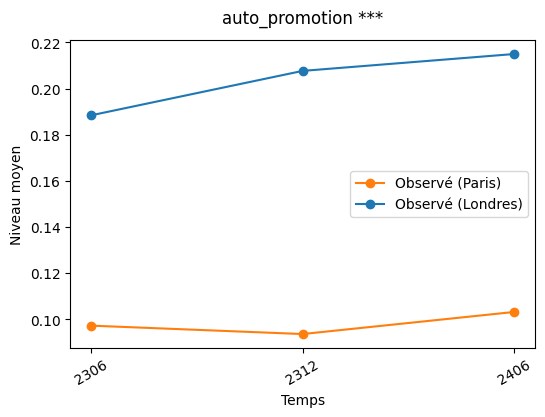

In [347]:
def plot_one_cf(cf_data, axes=None, i=0,  var="authenticité", title=None, ylabel=None, cf=False):
    if not axes:
        fig, ax=plt.subplots(figsize=(6,4))
    else :
        ax=axes[i]

    sub=cf_data[cf_data['variable']==var]
    # display(sub)
    
    x=list(range(len(sub['time'].unique())))
    # print("axis x :", x)
    
    ## plt
    paris = sub[sub["in_paris"] == 1]    
    # ---paris obs---
    ax.plot(
        x,
        # paris["time"],#.map(time_map),        
        paris["y_hat"],
        marker="o",
        label="Observé (Paris)",
        color='tab:orange'
    )    
    
    if cf==True:
        # ---paris cf---
        ax.plot(
            x,
            # paris["time"],#.map(time_map),
            paris["y_cf"],
            marker="o",
            linestyle="--",
            label="Contrefactuel(Paris)",
            color='tab:orange'
        )
        # + sig
        ddd_sig=sub[(sub['in_paris']==1)&(sub['time']=="2406")]['sig'].iloc[0]
        xi,yi, sig=2, paris[paris["time"]=="2406"]['y_cf'].iloc[0],ddd_sig
        ax.text(xi, yi + 0.002, sig, ha='center', 
            color='tab:orange', fontsize=12)
    
    
    # ---london obs---
    control = sub[sub["in_paris"] == 0]
    ax.plot(
        control["time"],#.map(time_map),
        control["y_hat"],
        marker="o",
        # alpha=0.4,
        label="Observé (Londres)",
        color='tab:blue'
    )
    
    ax.set_xticks(x)
    ax.set_xticklabels(sub['time'].unique())
    ax.tick_params(axis='x', rotation=30)
    
    ylabel="Niveau moyen" if ylabel is None else ylabel
    ax.set_ylabel(ylabel)
    ax.set_xlabel("Temps")

    title=var if title==None else title
    ddd_sig=sub[(sub['in_paris']==1)&(sub['time']=="2406")]['sig'].iloc[0]

    ax.set_title(f"{title} {ddd_sig}", pad=12)
    if not axes:
        ax.legend(fontsize=10)
        
    return 


df_plot=cf_data[cf_data['variable'].isin(tactics_bio)]
print(df_plot.variable.unique())
var='auto_promotion'

plot_one_cf(cf_data=df_plot, axes=None, i=0,  var=var, title=None, ylabel=None)
    
    
# plot_one_cf(agg_data, axes=None, i=0,  var=var, ddd_data=ddd_data, title=None, ylabel=None)


tactics:  ['ouverture' 'authenticité' 'sociabilité' 'auto_promotion' 'exemplarité']


C:\Users\yeliu\AppData\Local\Temp\ipykernel_18128\152659142.py:55: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0.1, 1,1])


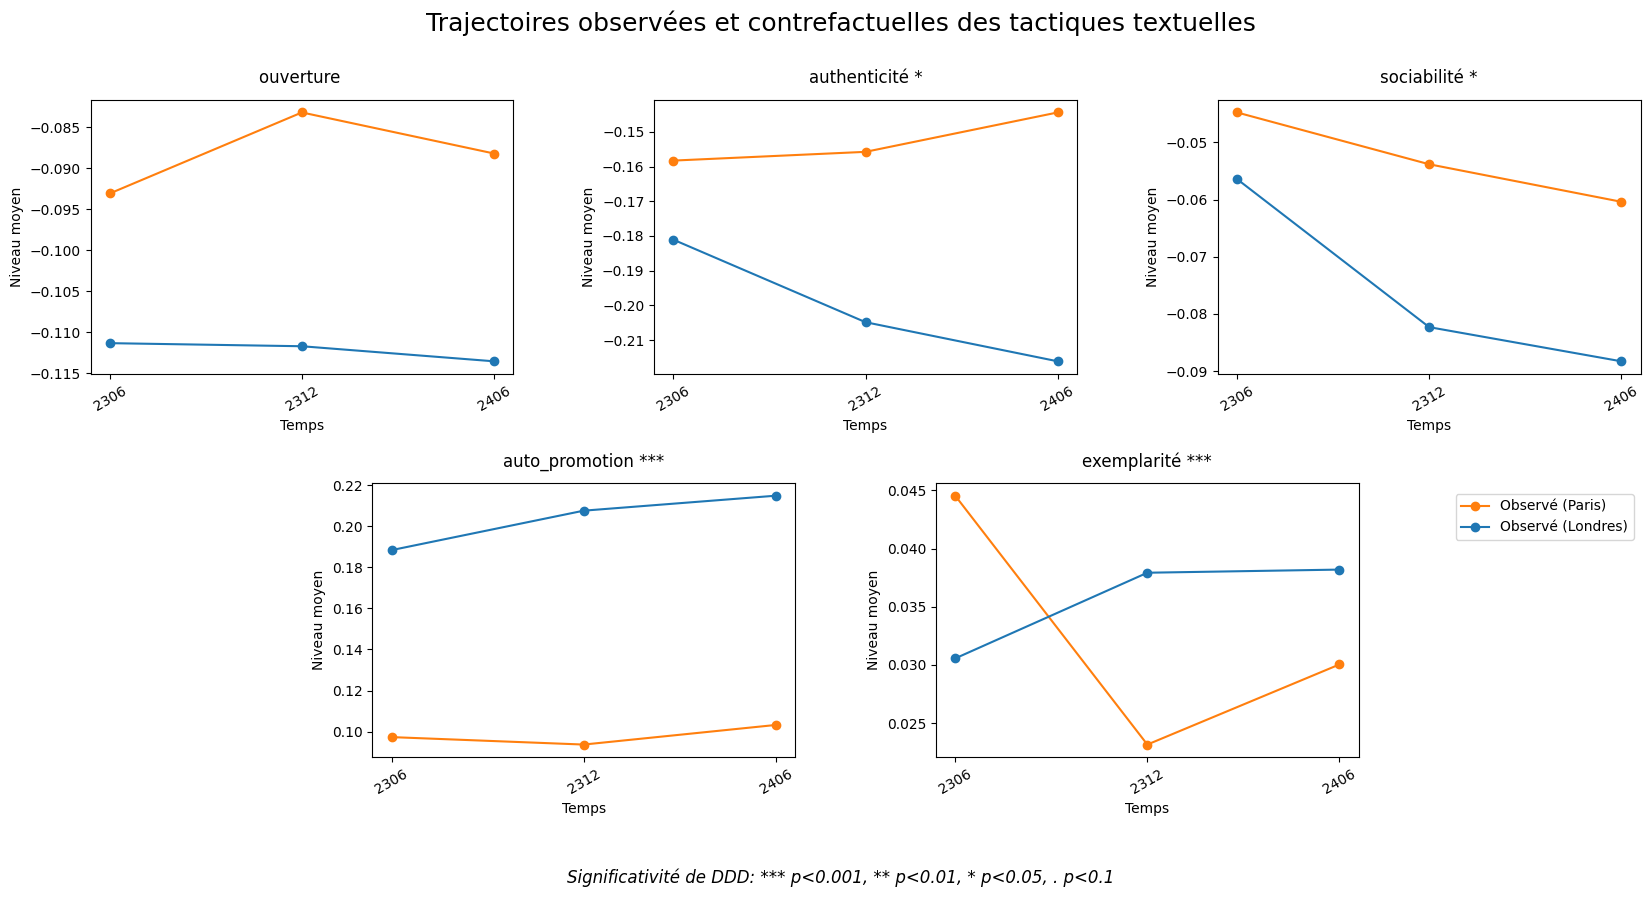

In [348]:
# ---layout---
# 使用更细的列分辨率（2 行 × 6 列），方便把第二行两个图放在中间列
fig = plt.figure(figsize=(20,9))# sharey=True
gs = gridspec.GridSpec(2, 6, figure=fig, hspace=0.4, wspace=1)

axes = []
# 第一行三个：分别占两列宽 (0:2, 2:4, 4:6)
ax1 = fig.add_subplot(gs[0, 0:2])
ax2 = fig.add_subplot(gs[0, 2:4])
ax3 = fig.add_subplot(gs[0, 4:6])
axes.extend([ax1, ax2, ax3])

# 第二行两个：让它们居中，分别占中间的两列 (1:3 和 3:5)
ax4 = fig.add_subplot(gs[1, 1:3])
ax5 = fig.add_subplot(gs[1, 3:5])
axes.extend([ax4, ax5])

# 确保 tactics_vars 长度为 5（或小于等于 len(axes)）
n_to_plot = min(len(tactics_bio), len(axes))


## plot:

df_plot=cf_data[cf_data['variable'].isin(tactics_bio)]
print('tactics: ',df_plot.variable.unique())
for i, var in enumerate(tactics_bio):
    plot_one_cf(cf_data=df_plot, axes=axes, i=i,  var=var, title=None, ylabel=None)
    

# layout:
fig.suptitle(
        "Trajectoires observées et contrefactuelles des tactiques textuelles",
        fontsize=18,
        y=0.98
    )

# --------------------legend------------------------
from matplotlib.lines import Line2D
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(
    handles,
    labels,
    loc="upper right",
    bbox_to_anchor=(0.9,0.45) # legend (x, y)，x>1则在图外, y=0在底线
)

plt.figtext(
    0.5, 0.01,
    "Significativité de DDD: *** p<0.001, ** p<0.01, * p<0.05, . p<0.1",
    ha="center",
    fontsize=12,
    style="italic"   
)

plt.tight_layout(rect=[0, 0.1, 1,1])
plt.subplots_adjust(bottom=0.15)#控制子图到底的距离，给text留出空间
plt.show()

# authen，auto，exem上升，ouv不显著变化，socio下降
# 但是jo都有提升效果！


tactics:  ['is_portrait' 'is_lifestyle' 'no_person']


C:\Users\yeliu\AppData\Local\Temp\ipykernel_18128\1040203833.py:58: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0.1, 0.8,1])


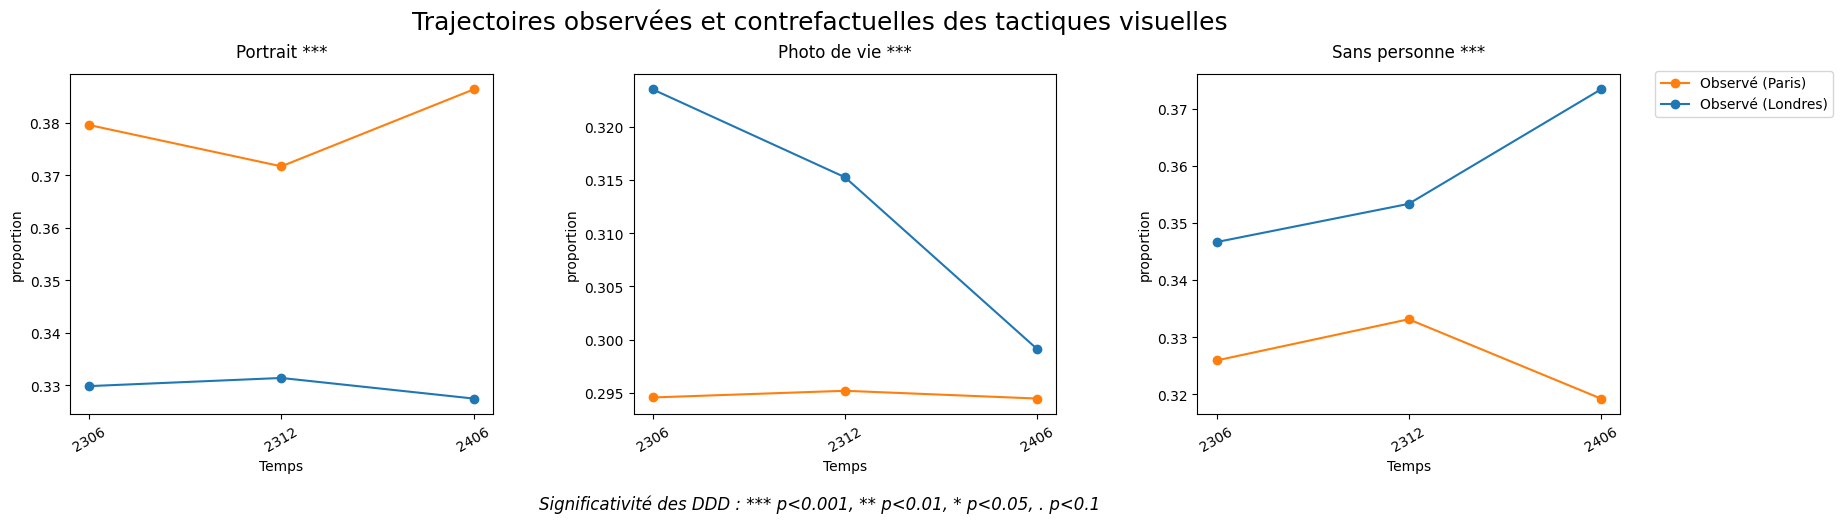

In [349]:
# ---layout---
# 使用更细的列分辨率（2 行 × 6 列），方便把第二行两个图放在中间列
fig = plt.figure(figsize=(20,5))# sharey=True
gs = gridspec.GridSpec(1, 6, figure=fig, hspace=0.4, wspace=1)

axes = []
# 第一行三个：分别占两列宽 (0:2, 2:4, 4:6)
ax1 = fig.add_subplot(gs[0, 0:2])
ax2 = fig.add_subplot(gs[0, 2:4])
ax3 = fig.add_subplot(gs[0, 4:6])
axes.extend([ax1, ax2, ax3])

# # 第二行两个：让它们居中，分别占中间的两列 (1:3 和 3:5)
# ax4 = fig.add_subplot(gs[1, 1:3])
# ax5 = fig.add_subplot(gs[1, 3:5])
# axes.extend([ax4, ax5])

# 确保 tactics_vars 长度为 5（或小于等于 len(axes)）
n_to_plot = min(len(tactics_bio), len(axes))


## plot:
df_plot=cf_data[cf_data['variable'].isin(tactics_pic_dummies)]#**
print('tactics: ',df_plot.variable.unique())

title_map={
    'is_portrait':'Portrait',
    'is_lifestyle':'Photo de vie',
    "no_person":"Sans personne"
}
for i, var in enumerate(tactics_pic_dummies):#**
    plot_one_cf(cf_data=df_plot, axes=axes, i=i,  var=var, title=title_map.get(var,""), ylabel='proportion')
      
# layout:
fig.suptitle(
        "Trajectoires observées et contrefactuelles des tactiques visuelles",
        fontsize=18,
        y=1.01
    )

# --------------------legend------------------------
from matplotlib.lines import Line2D
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(
    handles,
    labels,
    loc="upper right",
    bbox_to_anchor=(1.01,0.9) # legend (x, y)，x>1则在图外, y=0在底线
)
plt.figtext(
    0.5, 0.01,
    "Significativité des DDD : *** p<0.001, ** p<0.01, * p<0.05, . p<0.1",
    ha="center",
    fontsize=12,
    style="italic"   
)

plt.tight_layout(rect=[0, 0.1, 0.8,1])
plt.subplots_adjust(bottom=0.2)#控制子图到底的距离，给text留出空间
plt.show()
## ddd只能说明paris相对于london的变化，但是不知道是paris提升还是london下降，比如lifestyle中就是paris不变，但是london大幅下降了

# 总体上por上升，vie不变，sans下降！

## new old

In [430]:
from scipy import stats


var_map={
    'is_portrait':'portrait',
    'is_lifestyle':'photo de vie',
    'no_person':'sans personne'
}
def ttest_new_old_alltime(df,in_paris=[0, 1], vars=['authenticité']):
    # check time & in_paris
    df_t=df.copy()        
    # df_t = df_t[df_t['time'].isin(times)]
    df_t = df_t[df_t['in_paris'].isin(in_paris)]

    print(df.shape, '=>', df_t.shape)
    
    groups_in_paris=df_t['in_paris'].unique()
    # groups_time=df_t['time'].unique()
    # print(groups_in_paris)
    
    rows=[]
    for p in groups_in_paris:        
        for var in vars:
            sub = df_t[(df_t['in_paris'] == p)]# impo!!
            new = sub[sub['is_new_host'] == 1][var].dropna()
            old = sub[sub['is_new_host'] == 0][var].dropna()

            t_stat, p_value = stats.ttest_ind(new, old, equal_var=False)
            sig=p_to_sig(p_value)
            
            row_new= pd.DataFrame({
                # "time": [time],
                "in_paris":[p],
                "variable":var,
                "t_stat": [t_stat],
                "p_value": [p_value],
                "sig":[sig],
                'is_new_host':1,
                'mean':[new.mean()],
                'label':f"{var_map.get(var,'') if var in var_map.keys() else var}"
            })
            
            row_old= pd.DataFrame({
                # "time": [time],
                "in_paris":[p],
                "variable":var,
                "t_stat": [t_stat],
                "p_value": [p_value],
                "sig":[sig],
                'is_new_host':0,
                'mean':[old.mean()],
                'label':f"{var_map.get(var,'') if var in var_map.keys() else var}"
            })
            
            rows.append(row_new)
            rows.append(row_old)
    return pd.concat(rows, axis=0)


# ---plot data---    
ordered_tactics=tactics_bio + tactics_pic_dummies
# tactics=['authenticité']
df=df_all.copy()
tactcis_new_old_by_city=ttest_new_old_alltime(df,in_paris=[0, 1], vars=ordered_tactics)
tactcis_new_old_by_city

(266852, 131) => (266852, 131)


,in_paris,variable,t_stat,p_value,sig,is_new_host,mean,label
0,0,ouverture,18.487993,5.766969e-76,***,1,-0.043344,ouverture
0,0,ouverture,18.487993,5.766969e-76,***,0,-0.126196,ouverture
0,0,authenticité,33.313874,7.245170e-240,***,1,-0.068722,authenticité
0,0,authenticité,33.313874,7.245170e-240,***,0,-0.228354,authenticité
0,0,sociabilité,4.307344,1.656509e-05,***,1,-0.059650,sociabilité
0,0,sociabilité,4.307344,1.656509e-05,***,0,-0.079777,sociabilité
0,0,auto_promotion,-40.023552,0.000000e+00,***,1,0.042923,auto_promotion
0,0,auto_promotion,-40.023552,0.000000e+00,***,0,0.236918,auto_promotion
0,0,exemplarité,-12.152460,6.432120e-34,***,1,-0.008423,exemplarité
0,0,exemplarité,-12.152460,6.432120e-34,***,0,0.044618,exemplarité


in_paris=0, tactics:['ouverture', 'authenticité', 'sociabilité', 'auto_promotion', 'exemplarité']
10
in_paris=1, tactics:['ouverture', 'authenticité', 'sociabilité', 'auto_promotion', 'exemplarité']
10
in_paris=0, tactics:['is_portrait', 'is_lifestyle', 'no_person']
6
in_paris=1, tactics:['is_portrait', 'is_lifestyle', 'no_person']
6


C:\Users\yeliu\AppData\Local\Temp\ipykernel_18128\4006545166.py:96: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0.1, 1, 1])# [left, bottom, right, top]


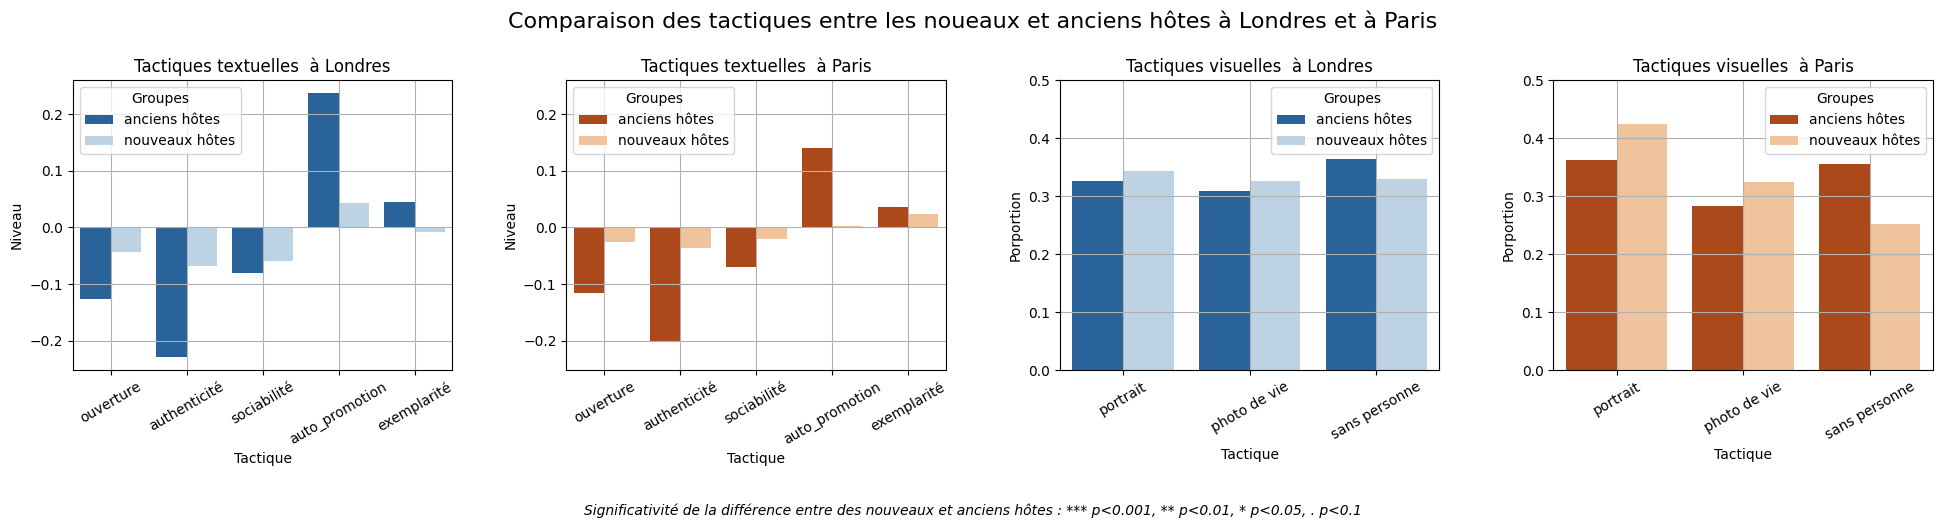

In [431]:

# ALL TIME london + paris NEW vs OLD

import matplotlib.pyplot as plt
importlib.reload(desc_new_old)
from utils.desc_new_old import ttest_new_old

# ---colors----
blue_cmap = plt.cm.Blues
orange_cmap = plt.cm.Oranges
n = 2 # ==len(hue) 每组柱子的数量
london_colors = blue_cmap(np.linspace(0.3, 0.8, n))
paris_colors  = orange_cmap(np.linspace(0.3, 0.8, n))
colors = (
    list(london_colors) +
    list(paris_colors)
)


## ---layout 4facets----
import matplotlib.gridspec as gridspec
fig = plt.figure(figsize=(24, 5)) 
gs = gridspec.GridSpec(1, 4, figure=fig, hspace=0.5, wspace=0.3)# 1行2列

axes = []
# 第一行两个：分别占两列宽 (0:2, 2:4, 4:6)
ax1 = fig.add_subplot(gs[0, 0:1])
ax2 = fig.add_subplot(gs[0, 1:2], sharey=ax1)#**
ax3 = fig.add_subplot(gs[0, 2:3], )#**
ax4 = fig.add_subplot(gs[0, 3:4], sharey=ax3)#**
axes.extend([ax1, ax2, ax3, ax4])

# ---plot---
df_plot=tactcis_new_old_by_city.copy()
tactics=tactics_bio+tactics_pic_dummies
subplot_col1='in_paris'
list_tactics=[tactics_bio, tactics_pic_dummies]

# subplot_col2='time'
i=0

for j, tactics in enumerate(list_tactics):
    for p in df_plot[subplot_col1].unique():
        print(f"{subplot_col1}={p}, tactics:{tactics}")
        ax=axes[i]
        
        # ---sub data---
        sub=df_plot[(df_plot[subplot_col1]==p)&(df_plot['variable'].isin(tactics))]
        print(len(sub))#==10==5 tactics *2 new/old
        
        if p==1:
            palette=dict(zip(sub['is_new_host'], paris_colors))
        else :
            palette=dict(zip(sub['is_new_host'], london_colors))
    
        sns.barplot(
            data=sub,   
            x='label',
            y="mean",
            hue="is_new_host",
            palette=palette,
            # order=ordered_tactics,
            ax=ax,
        )    

        ax.set_xlabel("Tactique")
        ax.set_ylabel(f"{'Niveau' if j==0 else 'Porportion'}")
        ax.tick_params(axis="x",rotation=30)
        if j==1:
            ax.set_ylim(0,0.5)
        
        ax.set_title(f"Tactiques {'textuelles' if j==0 else 'visuelles'}  à {'Paris' if p==1 else 'Londres'}")
        
        handles, labels = ax.get_legend_handles_labels()
        new_labels = ["anciens hôtes", "nouveaux hôtes"]
        ax.legend(handles, new_labels, title="Groupes")
        
        ax.grid()
        i+=1
        

## ---legend 2facets----
fig.suptitle(
        # "Effets marginaux des tactiques visuelles entre les groupes",
        "Comparaison des tactiques entre les noueaux et anciens hôtes à Londres et à Paris",
        fontsize=16,
        y=1.02
    )

plt.figtext(
    0.5, 0.01,
    "Significativité de la différence entre des nouveaux et anciens hôtes : *** p<0.001, ** p<0.01, * p<0.05, . p<0.1",
    ha="center",
    fontsize=10,
    style="italic",   
)
plt.tight_layout(rect=[0, 0.1, 1, 1])# [left, bottom, right, top]
plt.subplots_adjust(bottom=0.3)#控制子图到底的距离，给text留出空间
plt.show()


# 横截面差异（cross-sectional difference）
# 在任何一组中，新老房东的表现出不同的策略倾向：新房东ouv, authen, socio水平更高，但在auto, exem水平更低
# ttest属于描述，不解释因果！

# 从2312到2406,这个倾向是否是稳定的？是否发生变化?

In [185]:
## modeling
def p_to_sig(p):
    if p < 0.001: return '***'
    elif p < 0.01: return '**'
    elif p < 0.05: return '*'
    elif p < 0.1: return '.'
    else: return ''


specs=[
    # constants: time=2312-2406, in_paris: paris-london, 
    # is_new_host, terms 
    (1, """
        in_paris:C(time)[T.2406]:is_new_host
        - in_paris:C(time)[T.2312]:is_new_host
        """), 
    # - C(time)[T.2406]:is_new_host
    # + C(time)[T.2312]:is_new_host
        
    (0, """
        in_paris:C(time)[T.2406]
        - in_paris:C(time)[T.2312]
        """) 
#       - C(time)[T.2406]
#         + C(time)[T.2312]
]

df=df_all.copy()
results=[]

for var in tactics_bio+tactics_pic_dummies:
    print(var)
    formula= (f"{var} ~ C(host_identity_verified)  + review_scores_rating + has_rating +"
            "number_of_reviews_ltm + "
            "C(host_is_superhost) +"
            "years_since_host + professional_host + "
            "host_response_rate +  C(host_response_time)+"
            "has_text + lang_en + lang_fr + text_length+"
            "price  + availability_90 + C(room_type) + C(instant_bookable) + "
            "C(time) + in_paris * C(time)*is_new_host"
    )
    model_new=smf.ols(formula, data=df).fit()

    for i, (new, term) in enumerate(specs):
        test = model_new.t_test(term)
        sig=p_to_sig(test.pvalue)
        res= pd.DataFrame({
            'variable':var,
            "is_new_host":new,
            "coef": test.effect[0],
            "se": test.sd[0],
            "pval": test.pvalue,
            "sig":sig,
            "ci_low": test.conf_int()[0][0],
            "ci_high": test.conf_int()[0][1],
            'label':f"{var}{sig}"
        })
        results.append(res)
    # break

results_ddd_new=pd.concat(results, axis=0)
display(results_ddd_new)  


ouverture
authenticité
sociabilité
auto_promotion
exemplarité
is_portrait
is_lifestyle
no_person


,variable,is_new_host,coef,se,pval,sig,ci_low,ci_high,label
0,ouverture,1,-0.054887,0.013030,2.526307e-05,***,-0.080425,-0.029350,ouverture***
0,ouverture,0,0.006926,0.007089,3.285956e-01,,-0.006969,0.020821,ouverture
0,authenticité,1,0.017398,0.013490,1.971377e-01,,-0.009041,0.043838,authenticité
0,authenticité,0,-0.004878,0.007340,5.063110e-01,,-0.019263,0.009508,authenticité
0,sociabilité,1,0.046684,0.013950,8.185835e-04,***,0.019342,0.074026,sociabilité***
0,sociabilité,0,-0.011947,0.007590,1.154902e-01,,-0.026824,0.002930,sociabilité
0,auto_promotion,1,-0.007361,0.012715,5.626725e-01,,-0.032282,0.017561,auto_promotion
0,auto_promotion,0,0.034360,0.006918,6.820463e-07,***,0.020800,0.047920,auto_promotion***
0,exemplarité,1,0.070282,0.013512,1.979308e-07,***,0.043799,0.096765,exemplarité***
0,exemplarité,0,-0.004086,0.007352,5.783685e-01,,-0.018495,0.010324,exemplarité


is_new_host=1
is_new_host=0


C:\Users\yeliu\AppData\Local\Temp\ipykernel_18128\221536136.py:88: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0.1, 1, 1])# [left, bottom, right, top]


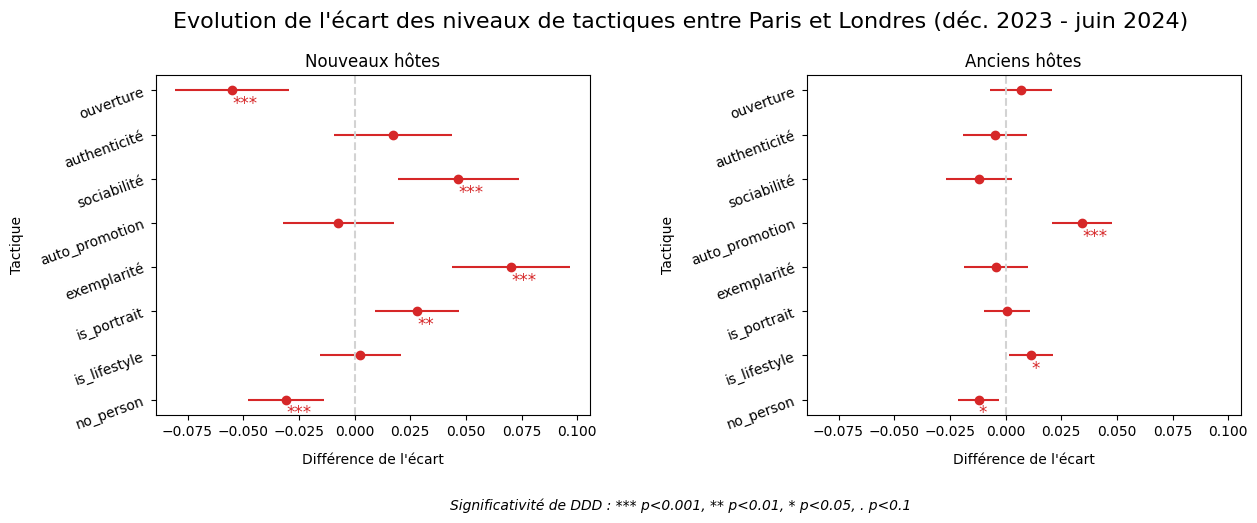

In [428]:
# # ---colors----
# blue_cmap = plt.cm.Blues
# orange_cmap = plt.cm.Greens
# n = 2 # 每组柱子的数量
# london_colors = blue_cmap(np.linspace(0.3, 0.8, n))
# paris_colors  = orange_cmap(np.linspace(0.5, 0.8, n))


## ---layout 2facets----
import matplotlib.gridspec as gridspec
fig = plt.figure(figsize=(14, 5)) 
gs = gridspec.GridSpec(1, 2, figure=fig, hspace=0.5, wspace=0.5)# 1行2列

axes = []
# 第一行两个：分别占两列宽 (0:2, 2:4, 4:6)
ax1 = fig.add_subplot(gs[0, 0:1])
ax2 = fig.add_subplot(gs[0, 1:2], sharex=ax1)#**
axes.extend([ax1, ax2])





# change_colors=plt.cm.Reds(np.linspace(0.6, 0.9, 2))
change_colors='tab:red'


#
tactics=tactics_bio+tactics_pic_dummies

df_plot=results_ddd_new[results_ddd_new['variable'].isin(tactics)].copy()#***

subplot_col="is_new_host"

for i, new in enumerate(df_plot[subplot_col].unique()):
    print(f"{subplot_col}={new}")
    
    sub=df_plot[df_plot[subplot_col]==new].copy()
    order=tactics[::-1]
    sub = sub.set_index("variable").loc[order].reset_index()
    # display(sub)

    ax=axes[i]
    ax.errorbar(
        x=sub["coef"],
        y=sub["variable"],
        # y=y,
        xerr=[sub["coef"] - sub["ci_low"], sub["ci_high"] - sub["coef"]],
        fmt='o', 
        color=change_colors,
        # linestyle='-' if new==1 else '--'
    )
    # ---sig---
    for _, row in sub.iterrows():
        ax.annotate(
            row["sig"],
            xy=(row["coef"], row["variable"]),
            xytext=(0, -10),         
            textcoords='offset points',
            ha='left',
            va='center',
            fontsize=12,
            color=change_colors
    )    
            
    ax.axvline(0, linestyle='--', color="lightgray", label="Changement de Londres")    
    ax.set_xlabel(f"Différence de l'écart", labelpad=10)
    ax.set_ylabel('Tactique', labelpad=10)
    ax.tick_params(axis='y', rotation=20)
    ax.set_title(f"{'Nouveaux hôtes' if new==1 else 'Anciens hôtes'}")
    
    

## ---legend 2facets----
fig.suptitle(
    "Evolution de l'écart des niveaux de tactiques entre Paris et Londres (déc. 2023 - juin 2024)", 
    fontsize=16,
    y=1.01
)

plt.figtext(
    0.5, 0.01,
    "Significativité de DDD : *** p<0.001, ** p<0.01, * p<0.05, . p<0.1",
    ha="center",
    fontsize=10,
    style="italic",   
)
plt.tight_layout(rect=[0, 0.1, 1, 1])# [left, bottom, right, top]
plt.subplots_adjust(bottom=0.2)#控制子图到底的距离，给text留出空间
plt.show()

# xin新房东减少noperson，老房东也减少noperson，增加life??

In [ ]:
# 每个时期地点类型房东的平均值
importlib.reload(desc_new_old)
from utils.desc_new_old import ttest_by_time

df_plot_time=ttest_by_time(df=df_all, 
                           times=["2312","2406"], in_paris=[0, 1], is_new_host=[0, 1], 
                           vars=tactics_bio+tactics_pic_dummies)
df_plot_time

(266852, 129) => (191595, 129)
is_new_host  time  in_paris
0            2406  0           37937
                   1           34176
             2312  0           32360
1            2406  1           28562
0            2312  1           24780
1            2406  0           11919
             2312  1           11049
                   0           10812
Name: count, dtype: int64


,time,in_paris,variable,t_stat,p_value,sig,is_new_host,mean,label,change
0,2312,0,ouverture,-2.769081,0.005626,**,1,-0.054907,ouverture **,+
0,2406,0,ouverture,-2.769081,0.005626,**,1,-0.032854,ouverture **,+
0,2312,0,authenticité,0.048290,0.961486,,1,-0.068509,authenticité,-
0,2406,0,authenticité,0.048290,0.961486,,1,-0.068915,authenticité,-
0,2312,0,sociabilité,0.249636,0.802871,,1,-0.058570,sociabilité,-
...,...,...,...,...,...,...,...,...,...,...
0,2406,1,is_portrait,2.771907,0.005575,**,0,0.347817,is_portrait **,-
0,2312,1,is_lifestyle,2.238904,0.025166,*,0,0.279742,is_lifestyle *,-
0,2406,1,is_lifestyle,2.238904,0.025166,*,0,0.271389,is_lifestyle *,-
0,2312,1,no_person,-4.821333,0.000001,***,0,0.361380,no_person ***,+


0
variable=ouverture, is_new_host=1
variable=ouverture, is_new_host=0
1
variable=authenticité, is_new_host=1
variable=authenticité, is_new_host=0
2
variable=sociabilité, is_new_host=1
variable=sociabilité, is_new_host=0
3
variable=auto_promotion, is_new_host=1
variable=auto_promotion, is_new_host=0
4
variable=exemplarité, is_new_host=1
variable=exemplarité, is_new_host=0


C:\Users\yeliu\AppData\Local\Temp\ipykernel_18128\1880137116.py:127: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0.1, 0.8, 1])# [left, bottom, right, top]


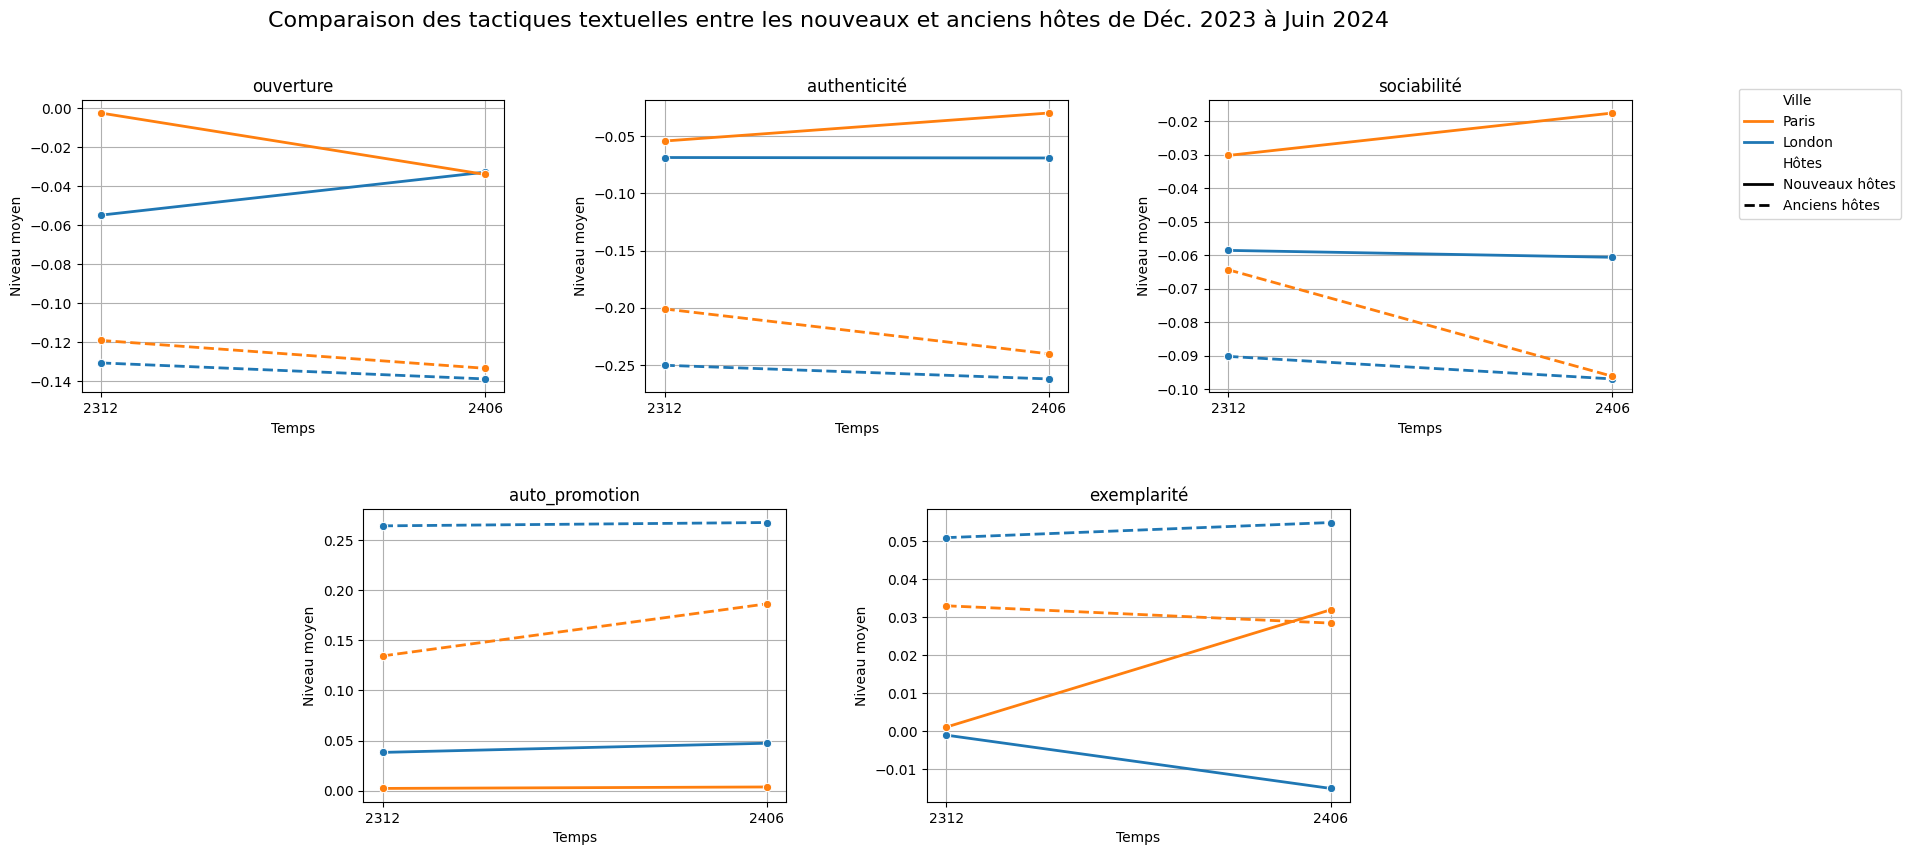

In [425]:
## new old hue:london/paris y=tactics_sig
import matplotlib.gridspec as gridspec

# ---colors----
blue_cmap = plt.cm.Blues
orange_cmap = plt.cm.Oranges
n = 1 # ==len(hue) 每组柱子的数量
# london_colors = blue_cmap(np.linspace(0.7, 0.8, n))
# paris_colors  = orange_cmap(np.linspace(0.7, 0.8, n))

london_colors="tab:blue"
paris_colors='tab:orange'
# paris:paris color
palette={
    0:london_colors,
    1:paris_colors
}


# -------------------layout 5 facets-------------------
# 使用更细的列分辨率（2 行 × 6 列），方便把第二行两个图放在中间列
fig = plt.figure(figsize=(20,9))
gs = gridspec.GridSpec(2, 6, figure=fig, hspace=0.4, wspace=1)

axes = []
# # 第一行三个：分别占两列宽 (0:2, 2:4, 4:6)
ax1 = fig.add_subplot(gs[0, 0:2])
ax2 = fig.add_subplot(gs[0, 2:4])
ax3 = fig.add_subplot(gs[0, 4:6])
axes.extend([ax1, ax2, ax3])

# 第二行两个：让它们居中，分别占中间的两列 (1:3 和 3:5)
ax4 = fig.add_subplot(gs[1, 1:3])
ax5 = fig.add_subplot(gs[1, 3:5])
axes.extend([ax4, ax5])

# 确保 tactics_vars 长度为 5（或小于等于 len(axes)）
n_to_plot = min(len(tactics_bio), len(axes))


df_plot=df_plot_time.copy()
# 每一个tac一个图，一个图中新老pl四条线, 新房东浅色，london蓝色，
# 每个 var 一张图
# x = time
# 线 = Paris vs London
# hue = new/old


subplot_col1='variable'
subplot_col2='is_new_host'
# subplot_col3='is_new_host'
tactics=tactics_bio

i=0
for var in tactics:
    ax=axes[i]
    print(i)    
    for new in df_plot[subplot_col2].unique():#*** 
       
                    
        # ---sub data---
        print(f"{subplot_col1}={var}, {subplot_col2}={new}")#***        
        sub = df_plot[
            (df_plot[subplot_col1] == var) &
            (df_plot[subplot_col2] == new) 
        ].copy()
        # display(sub)
        # new/old
    
        sns.lineplot(
            data=sub,
            x="time",
            y="mean",
            hue="in_paris",
            palette=palette,
            marker="o",
            linestyle='-' if new==1 else '--',
            linewidth= 2,# if new==1 else 1.5,
            ax=ax,
            legend=False
        )
        # break
            
    ax.grid()
    ax.set_xlabel("Temps")
    ax.set_ylabel("Niveau moyen")
    ax.set_title(f"{var}")
    i+=1
    # break        
            
    
## ---legend 2facets----
fig.suptitle(
        f"Comparaison des tactiques textuelles entre les nouveaux et anciens hôtes de Déc. 2023 à Juin 2024 ",
        fontsize=16,
        y=0.98
    )
# ---custom legen---
legend_elements = []
    # ---标题：城市---
legend_elements.append(Line2D([], [], linestyle="none", label="Ville"))

legend_elements.append(
    Line2D([0], [0], color=paris_colors, lw=2, linestyle="-", label="Paris")
)
legend_elements.append(
    Line2D([0], [0], color=london_colors, lw=2, linestyle="-", label="London")
)

# ---标题：新老房东---
legend_elements.append(Line2D([], [], linestyle="none", label="Hôtes"))

legend_elements.append(
    Line2D([0], [0], color="black", lw=2, linestyle="-", label="Nouveaux hôtes")
)
legend_elements.append(
    Line2D([0], [0], color="black", lw=2, linestyle="--", label="Anciens hôtes")
)

fig.legend(
        handles=legend_elements,
        loc="upper left",
        bbox_to_anchor=(0.95, 0.9),
        frameon=True
    )

plt.tight_layout(rect=[0, 0.1, 0.8, 1])# [left, bottom, right, top]
plt.subplots_adjust(bottom=0.1)#控制子图到底的距离，给text留出空间

plt.show()

0
variable=is_portrait, is_new_host=1
variable=is_portrait, is_new_host=0
1
variable=is_lifestyle, is_new_host=1
variable=is_lifestyle, is_new_host=0
2
variable=no_person, is_new_host=1
variable=no_person, is_new_host=0


C:\Users\yeliu\AppData\Local\Temp\ipykernel_18128\604674308.py:118: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0.1, 0.8, 1])# [left, bottom, right, top]


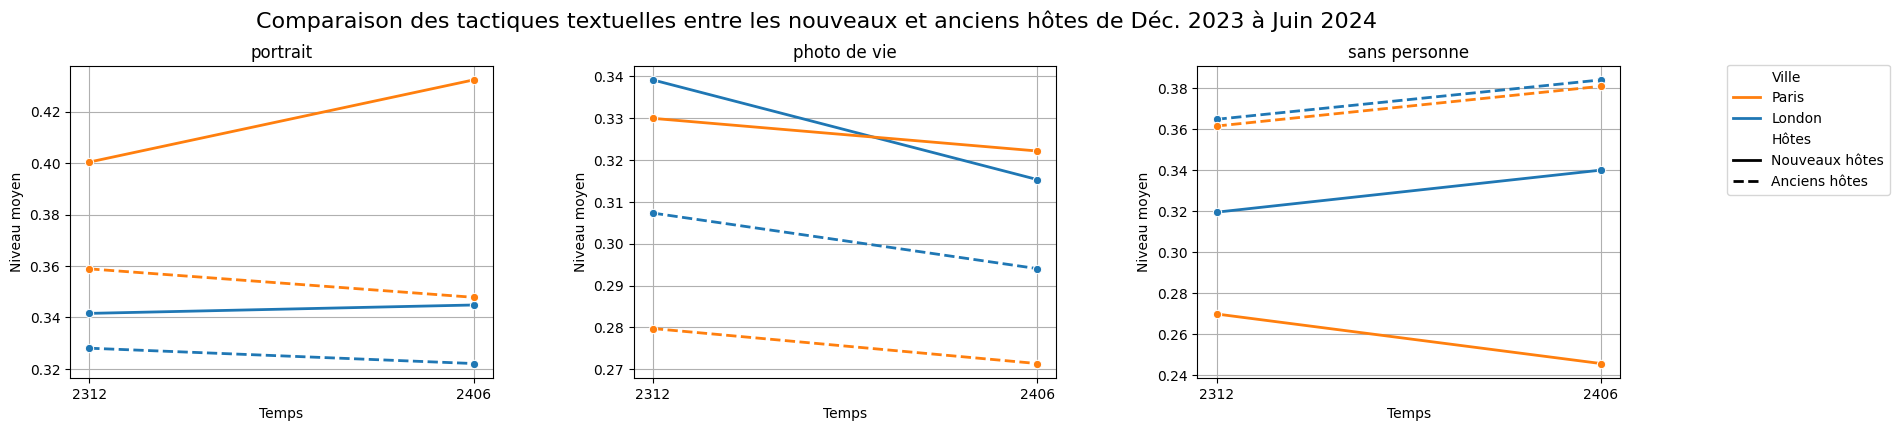

In [426]:
## new old hue:london/paris y=tactics_sig
import matplotlib.gridspec as gridspec
tactics=tactics_pic_dummies
df_plot=df_plot_time.copy()

# paris:paris color
palette={
    0:'tab:blue',
    1:'tab:orange'
}

# -------------------layout 5 facets-------------------
# 使用更细的列分辨率（2 行 × 6 列），方便把第二行两个图放在中间列
fig = plt.figure(figsize=(20,4))
gs = gridspec.GridSpec(1, 6, figure=fig, hspace=0.4, wspace=1)

axes = []
# # 第一行三个：分别占两列宽 (0:2, 2:4, 4:6)
ax1 = fig.add_subplot(gs[0, 0:2])
ax2 = fig.add_subplot(gs[0, 2:4])
ax3 = fig.add_subplot(gs[0, 4:6])
axes.extend([ax1, ax2, ax3])

# 确保 tactics_vars 长度为 5（或小于等于 len(axes)）
n_to_plot = min(len(tactics), len(axes))


df_plot=df_plot_time.copy()
# 每一个tac一个图，一个图中新老pl四条线, 新房东浅色，london蓝色，
# 每个 var 一张图
# x = time
# 线 = Paris vs London
# hue = new/old


subplot_col1='variable'
subplot_col2='is_new_host'

i=0
for var in tactics:
    ax=axes[i]
    print(i)    
    for new in df_plot[subplot_col2].unique():#*** 
       
                    
        # ---sub data---
        print(f"{subplot_col1}={var}, {subplot_col2}={new}")#***        
        sub = df_plot[
            (df_plot[subplot_col1] == var) &
            (df_plot[subplot_col2] == new) 
        ].copy()
        # display(sub)
        # new/old
    
        sns.lineplot(
            data=sub,
            x="time",
            y="mean",
            hue="in_paris",
            palette=palette,
            marker="o",
            linestyle='-' if new==1 else '--',
            linewidth= 2, # if new==1 else 1.5,
            ax=ax,
            legend=False
        )
        # break
        
    ax.grid()
    ax.set_xlabel("Temps")
    ax.set_ylabel("Niveau moyen")
    var_map={
        'is_portrait':"portrait",
        "is_lifestyle":'photo de vie',
        "no_person":'sans personne'
    }
    ax.set_title(f"{var_map.get(var,'')}")
    i+=1
    # break        
            
    
## ---legend 2facets----
fig.suptitle(
        f"Comparaison des tactiques textuelles entre les nouveaux et anciens hôtes de Déc. 2023 à Juin 2024 ",
        fontsize=16,
        y=1.02
    )

# ---custom legend---
legend_elements = []
    # ---标题：城市---
legend_elements.append(Line2D([], [], linestyle="none", label="Ville"))

legend_elements.append(
    Line2D([0], [0], color=paris_colors, lw=2, linestyle="-", label="Paris")
)
legend_elements.append(
    Line2D([0], [0], color=london_colors, lw=2, linestyle="-", label="London")
)

# ---标题：新老房东---
legend_elements.append(Line2D([], [], linestyle="none", label="Hôtes"))

legend_elements.append(
    Line2D([0], [0], color="black", lw=2, linestyle="-", label="Nouveaux hôtes")
)
legend_elements.append(
    Line2D([0], [0], color="black", lw=2, linestyle="--", label="Anciens hôtes")
)

fig.legend(
        handles=legend_elements,
        loc="upper left",
        bbox_to_anchor=(0.95, 0.9),
        frameon=True
    )

plt.tight_layout(rect=[0, 0.1, 0.8, 1])# [left, bottom, right, top]
plt.subplots_adjust(bottom=0.1)#控制子图到底的距离，给text留出空间

plt.show()

is_new_host=1, in_paris=0
is_new_host=1, in_paris=1
is_new_host=0, in_paris=0
is_new_host=0, in_paris=1


C:\Users\yeliu\AppData\Local\Temp\ipykernel_18128\3835108691.py:110: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0.1, 1, 1])# [left, bottom, right, top]


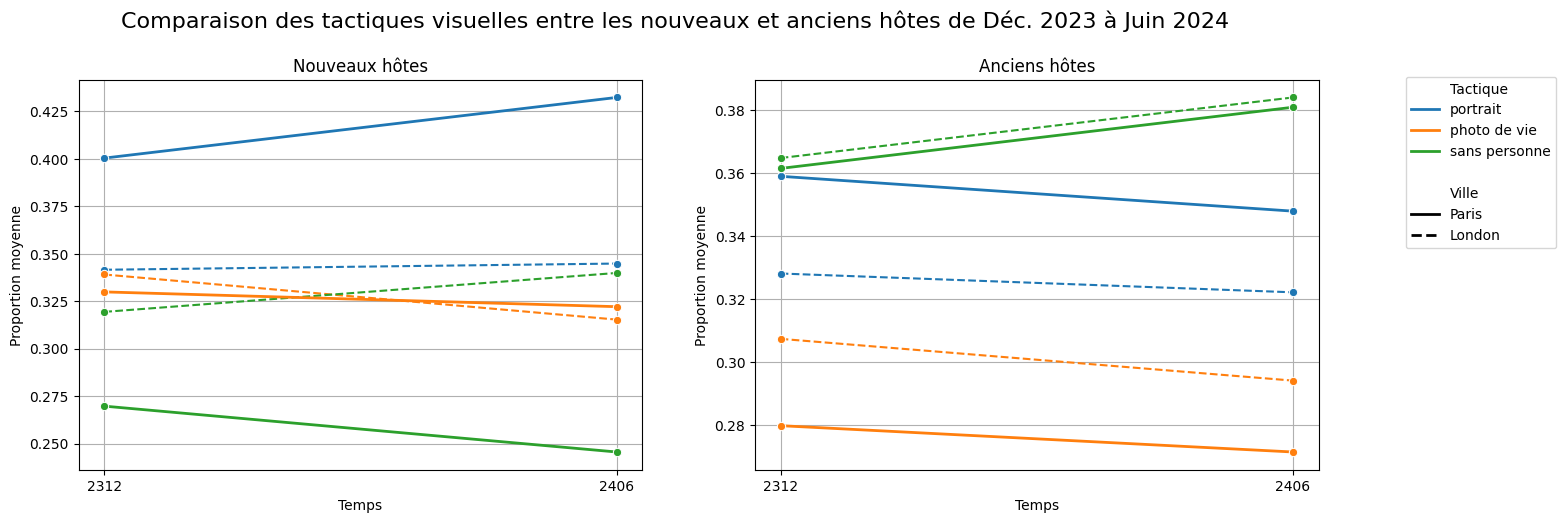

In [136]:
## new old hue:london/paris y=tactics_sig
## ---layout 2facets----
import matplotlib.gridspec as gridspec
fig = plt.figure(figsize=(16, 5)) # sharey=True
gs = gridspec.GridSpec(1, 2, figure=fig, hspace=0.5, wspace=0.2)# 1行2列

axes = []
# 第一行两个：分别占两列宽 (0:2, 2:4, 4:6)
ax1 = fig.add_subplot(gs[0, 0:1])
ax2 = fig.add_subplot(gs[0, 1:2])
axes.extend([ax1, ax2])


df_plot=df_plot_time.copy()
subplot_col1='is_new_host'
subplot_col2='in_paris'
tactics=tactics_pic_dummies#**


palette = {
    "ouverture": "#1f77b4",
    "authenticité": "#ff7f0e",
    "sociabilité": "#2ca02c",
    "auto_promotion": "#d62728",
    "exemplarité": "#9467bd",
    
    "is_portrait": "#1f77b4",
    "is_lifestyle": "#ff7f0e",
    "no_person": "#2ca02c",
}


for i, new in enumerate(df_plot[subplot_col1].unique()):
    ax=axes[i]
    
    # tactics_sig=['ouverture',"sociabilité","exemplarité"] if new==1 else ['auto_promotion'] 
    tactics_sig=tactics_pic_dummies#***
    for p in df_plot[subplot_col2].unique():#***
        print(f"{subplot_col1}={new}, {subplot_col2}={p}")#***        
        # ---sub data---
        sub=df_plot[(df_plot[subplot_col1]==new)&(df_plot[subplot_col2]==p)&(df_plot['variable'].isin(tactics_sig))]#***
        # display(sub)
        # print(len(sub))#=5 tactics*2 times=10
        
        sns.lineplot(
            data=sub,
            x='time',#***hue
            y="mean",
            hue="variable",
            marker="o",
            linestyle='-' if p==1 else '--',
            linewidth= 2 if p==1 else 1.5,
            palette=palette,
            legend=False,
            ax=ax,
        )

    ax.grid()
    ax.set_xlabel("Temps")
    ax.set_ylabel("Proportion moyenne")
    # ax.tick_params(axis="x",rotation=30)
    ax.set_title(f"{'Nouveaux hôtes' if new==1 else 'Anciens hôtes'}")

    # ax.add_artist(leg1)  # ❗保留第一个 legend
    from matplotlib.lines import Line2D

    legend_elements = []
    # ---标题：策略---
    legend_elements.append(Line2D([], [], linestyle="none", label="Tactique"))
    var_map={
        'is_portrait':"portrait",
        "is_lifestyle":'photo de vie',
        "no_person":'sans personne'
    }
    for var in tactics_sig:
        legend_elements.append(
        Line2D([0], [0], color=palette[var], lw=2, label=var_map.get(var, "") if var in var_map.keys() else var)
        )

    # ---空行---
    legend_elements.append(Line2D([], [], linestyle="none", label=""))

    # ---标题：城市---
    legend_elements.append(Line2D([], [], linestyle="none", label="Ville"))

    legend_elements.append(
        Line2D([0], [0], color="black", lw=2, linestyle="-", label="Paris")
    )
    legend_elements.append(
        Line2D([0], [0], color="black", lw=2, linestyle="--", label="London")
    )
    i+=1        
        
    # break

## ---legend 2facets----
fig.suptitle(
        f"Comparaison des tactiques visuelles entre les nouveaux et anciens hôtes de Déc. 2023 à Juin 2024 ",
        fontsize=16,
        y=1.02
    )

fig.legend(
        handles=legend_elements,
        loc="upper left",
        bbox_to_anchor=(0.95, 0.9),
        frameon=True
    )

plt.tight_layout(rect=[0, 0.1, 1, 1])# [left, bottom, right, top]
plt.subplots_adjust(bottom=0.1)#控制子图到底的距离，给text留出空间

plt.show()

in_paris=0, is_new_host=1
10
in_paris=0, is_new_host=0
10
in_paris=1, is_new_host=1
10
in_paris=1, is_new_host=0
10


C:\Users\yeliu\AppData\Local\Temp\ipykernel_18128\113358066.py:86: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0.1, 0.9, 1])# [left, bottom, right, top]


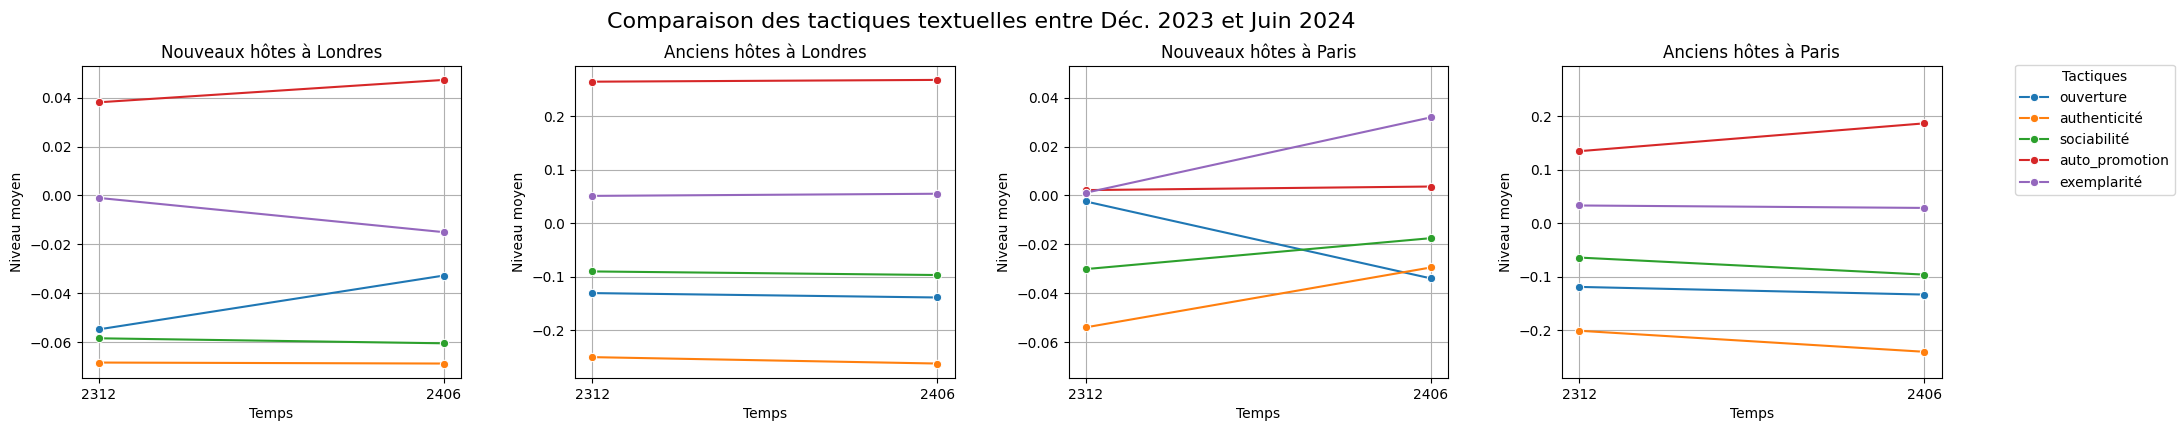

In [50]:
## london + paris new + old 2312 vs 2406
import matplotlib.pyplot as plt
importlib.reload(desc_new_old)
from utils.desc_new_old import ttest_new_old

# ---colors----
blue_cmap = plt.cm.Blues
orange_cmap = plt.cm.Oranges
n = 2 # ==len(hue) 每组柱子的数量
london_colors = blue_cmap(np.linspace(0.3, 0.8, n))
paris_colors  = orange_cmap(np.linspace(0.3, 0.8, n))
colors = (
    list(london_colors) +
    list(paris_colors)
)

## ---layout 2facets----
import matplotlib.gridspec as gridspec
fig = plt.figure(figsize=(24, 4)) 
gs = gridspec.GridSpec(1, 4, figure=fig, hspace=0.5, wspace=0.3)# 1行2列

axes = []
# 第一行两个：分别占两列宽 (0:2, 2:4, 4:6)
ax1 = fig.add_subplot(gs[0, 0:1])
ax2 = fig.add_subplot(gs[0, 1:2])#**
ax3 = fig.add_subplot(gs[0, 2:3], sharey=ax1)#**
ax4 = fig.add_subplot(gs[0, 3:4], sharey=ax2)#**
axes.extend([ax1, ax2, ax3, ax4])

# ---plot---
subplot_col1='in_paris'
subplot_col2='is_new_host'
tactics=tactics_bio
i=0
df_plot=df_plot_time.copy()
for p in df_plot[subplot_col1].unique():#***
    for new in df_plot[subplot_col2].unique():#***
        print(f"{subplot_col1}={p}, {subplot_col2}={new}")#***
        ax=axes[i]
        
        # ---sub data---
        sub=df_plot[(df_plot[subplot_col1]==p)&(df_plot[subplot_col2]==new)&(df_plot['variable'].isin(tactics))]#***
        # display(sub)
        print(len(sub))#=5 tactics*2 times=10
        
        sns.lineplot(
            data=sub,
            x='time',#***hue
            y="mean",
            hue="variable",
            marker="o",
            ax=ax
        )

        ax.set_xlabel("Temps")
        ax.set_ylabel("Niveau moyen")
        # ax.tick_params(axis="x",rotation=30)
        ax.set_title(f"{'Nouveaux hôtes' if new==1 else 'Anciens hôtes'} à {'Paris' if p==1 else 'Londres'}")
        if ax.legend():
            ax.get_legend().remove()
            
        # ax.legend(loc="upper left", bbox_to_anchor=(1.02, 1), borderaxespad=0)
        ax.grid()
        i+=1
        

## ---legend 2facets----
fig.suptitle(
        # "Effets marginaux des tactiques visuelles entre les groupes",
        "Comparaison des tactiques textuelles entre Déc. 2023 et Juin 2024",
        fontsize=16,
        y=1.02
    )


# plt.figtext(
#     0.5, 0.01,
#     "Significativité de la différence entre des nouveaux et anciens hôtes : *** p<0.001, ** p<0.01, * p<0.05, . p<0.1",
#     ha="center",
#     fontsize=10,
#     style="italic",   
# )

handles, labels = ax.get_legend_handles_labels()
fig.legend(handles, labels, title="Tactiques", loc="upper right", bbox_to_anchor=(1, 0.9))
plt.tight_layout(rect=[0, 0.1, 0.9, 1])# [left, bottom, right, top]
plt.subplots_adjust(bottom=0.1)#控制子图到底的距离，给text留出空间

plt.show()


#新老房东使用策略是否发生随时间发生显著变化？
# 先看平均水平：几乎都是是平行的

## ttest显著但是还需要检查效应量！极小的差异也可能显著cohensd

## 如果有jo冲击，paris新房东变化-london新房东变化显著， paris老房东变化-london老房东变化显著，
# 但新老房东显著的策略不同？

in_paris=0, is_new_host=1
6
in_paris=0, is_new_host=0
6
in_paris=1, is_new_host=1
6
in_paris=1, is_new_host=0
6


C:\Users\yeliu\AppData\Local\Temp\ipykernel_18128\1969020968.py:84: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0.1, 0.9, 1])# [left, bottom, right, top]


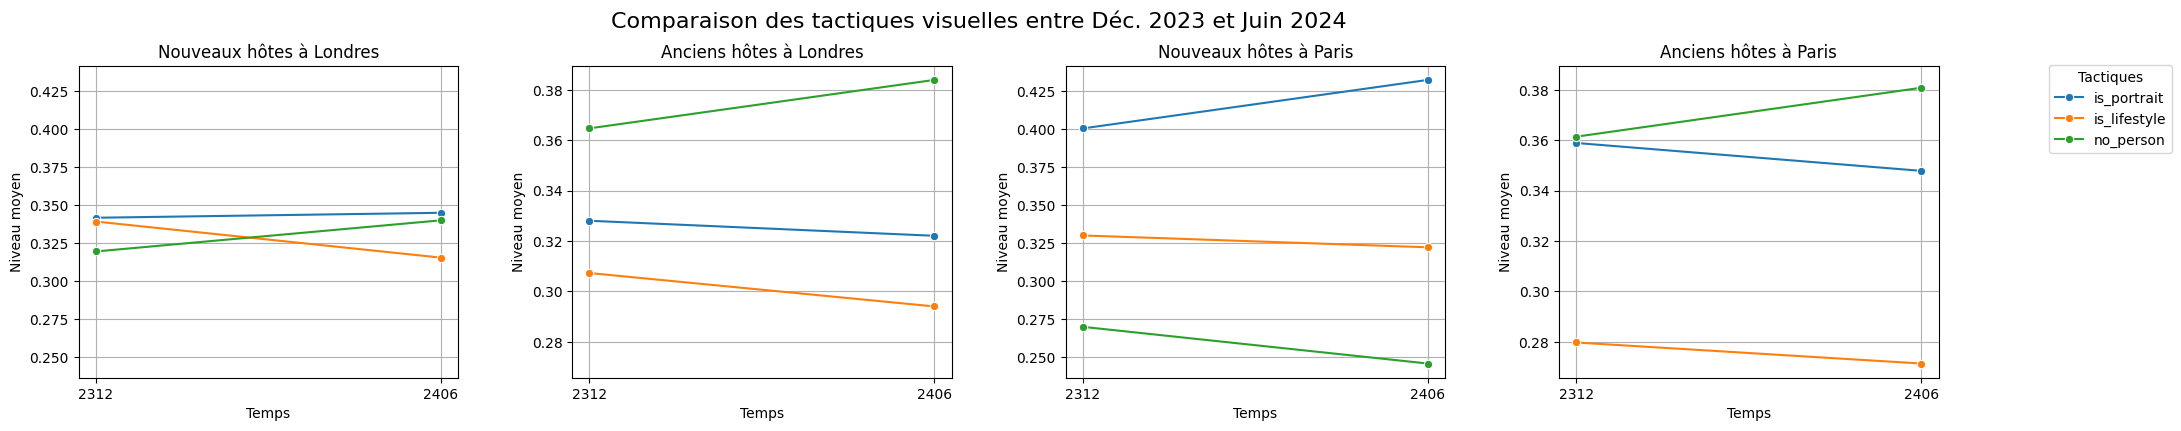

In [51]:
## london + paris new + old 2312 vs 2406
import matplotlib.pyplot as plt
importlib.reload(desc_new_old)
from utils.desc_new_old import ttest_new_old

# ---colors----
blue_cmap = plt.cm.Blues
orange_cmap = plt.cm.Oranges
n = 2 # ==len(hue) 每组柱子的数量
london_colors = blue_cmap(np.linspace(0.3, 0.8, n))
paris_colors  = orange_cmap(np.linspace(0.3, 0.8, n))
colors = (
    list(london_colors) +
    list(paris_colors)
)

## ---layout 2facets----
import matplotlib.gridspec as gridspec
fig = plt.figure(figsize=(24, 4)) 
gs = gridspec.GridSpec(1, 4, figure=fig, hspace=0.5, wspace=0.3)# 1行2列

axes = []
# 第一行两个：分别占两列宽 (0:2, 2:4, 4:6)
ax1 = fig.add_subplot(gs[0, 0:1])
ax2 = fig.add_subplot(gs[0, 1:2])#**
ax3 = fig.add_subplot(gs[0, 2:3], sharey=ax1)#**
ax4 = fig.add_subplot(gs[0, 3:4], sharey=ax2)#**
axes.extend([ax1, ax2, ax3, ax4])

# ---plot---
subplot_col1='in_paris'
subplot_col2='is_new_host'
tactics=tactics_pic_dummies
i=0
for p in df_plot[subplot_col1].unique():#***
    for new in df_plot[subplot_col2].unique():#***
        print(f"{subplot_col1}={p}, {subplot_col2}={new}")#***
        ax=axes[i]
        
        # ---sub data---
        sub=df_plot[(df_plot[subplot_col1]==p)&(df_plot[subplot_col2]==new)&(df_plot['variable'].isin(tactics))]#***
        # display(sub)
        print(len(sub))#=5 tactics*2 times=10
        
        sns.lineplot(
            data=sub,
            x='time',#***hue
            y="mean",
            hue="variable",
            marker="o",
            ax=ax
        )

        ax.set_xlabel("Temps")
        ax.set_ylabel("Niveau moyen")
        # ax.tick_params(axis="x",rotation=30)
        ax.set_title(f"{'Nouveaux hôtes' if new==1 else 'Anciens hôtes'} à {'Paris' if p==1 else 'Londres'}")
        if ax.legend():
            ax.get_legend().remove()
            
        # ax.legend(loc="upper left", bbox_to_anchor=(1.02, 1), borderaxespad=0)
        ax.grid()
        i+=1

## ---legend 2facets----
fig.suptitle(
        # "Effets marginaux des tactiques visuelles entre les groupes",
        "Comparaison des tactiques visuelles entre Déc. 2023 et Juin 2024",
        fontsize=16,
        y=1.02
    )


# plt.figtext(
#     0.5, 0.01,
#     "Significativité de la différence entre des nouveaux et anciens hôtes : *** p<0.001, ** p<0.01, * p<0.05, . p<0.1",
#     ha="center",
#     fontsize=10,
#     style="italic",   
# )

handles, labels = ax.get_legend_handles_labels()
fig.legend(handles, labels, title="Tactiques", loc="upper right", bbox_to_anchor=(1, 0.9))
plt.tight_layout(rect=[0, 0.1, 0.9, 1])# [left, bottom, right, top]
plt.subplots_adjust(bottom=0.1)#控制子图到底的距离，给text留出空间

plt.show()


# changment des effects des tactiques

In [362]:
df=df_all.copy()
formula= ("booking_rate_l90d ~ C(host_identity_verified)  + review_scores_rating + has_rating +"
        "number_of_reviews_ltm + "
        "C(host_is_superhost) +"
        "years_since_host + professional_host + "
        "host_response_rate +  C(host_response_time)+"
        "has_text + lang_en + lang_fr + text_length+"
        "price  + availability_90 + C(room_type) + C(instant_bookable) + "
        # "C(time) + in_paris+"
        "in_paris * C(time) *(ouverture + authenticité + sociabilité + auto_promotion + exemplarité + C(host_picture_type))"
)
df=df_all.copy()
model_interaction=smf.ols(formula, data=df).fit()
summary=model_interaction.summary()
print(summary)

                            OLS Regression Results                            
Dep. Variable:      booking_rate_l90d   R-squared:                       0.402
Model:                            OLS   Adj. R-squared:                  0.402
Method:                 Least Squares   F-statistic:                     2601.
Date:                Thu, 23 Apr 2026   Prob (F-statistic):               0.00
Time:                        15:52:14   Log-Likelihood:                 89010.
No. Observations:              266852   AIC:                        -1.779e+05
Df Residuals:                  266782   BIC:                        -1.771e+05
Df Model:                          69                                         
Covariance Type:            nonrobust                                         
                                                                 coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------

In [ ]:
tactics_pic_cat=["C(host_picture_type)[T.no_person]","C(host_picture_type)[T.pro_style]"]
var_map={
        "C(host_picture_type)[T.no_person]":"sans personne",
        "C(host_picture_type)[T.pro_style]":"portrait"
    }


def get_ddd_effect_interaction(model, var):
    """
    in_paris:C(time)[T.2406] - in_paris:C(time)[T.2312]    
    """
    if var :
        term=f"in_paris:C(time)[T.2406]:{var} - in_paris:C(time)[T.2312]:{var} = 0"
    # print(term)
    
    test=model.t_test(term)
    
    return pd.DataFrame({
            'variable':var,
            "coef": test.effect[0],
            "se": test.sd[0],
            "pval": test.pvalue,
            "sig":p_to_sig(test.pvalue),
            "ci_low": test.conf_int()[0][0],
            "ci_high": test.conf_int()[0][1],
            'label':f"{var_map.get(var,'') if var in var_map.keys() else var}"
        })
    
    
# ddd_int=get_ddd_effect_interaction(model=model_interaction, var="authenticité")
# ddd_int

results_ddd_tactic = pd.concat([
    get_ddd_effect_interaction(model=model_interaction, var=var)
    for var in tactics_bio+tactics_pic_cat
])
results_ddd_tactic



,variable,coef,se,pval,sig,ci_low,ci_high,label
0,ouverture,-0.003793,0.002994,0.205081,,-0.009661,0.002074,ouverture
0,authenticité,-0.010129,0.003037,0.000854,***,-0.016082,-0.004175,authenticité
0,sociabilité,-0.003074,0.002907,0.290375,,-0.008772,0.002624,sociabilité
0,auto_promotion,0.002930,0.003018,0.331754,,-0.002986,0.008846,auto_promotion
0,exemplarité,0.001896,0.002783,0.495737,,-0.003559,0.007350,exemplarité
0,C(host_picture_type)[T.no_person],0.016284,0.004194,0.000103,***,0.008064,0.024503,sans personne
0,C(host_picture_type)[T.pro_style],-0.004110,0.004022,0.306761,,-0.011993,0.003772,portrait


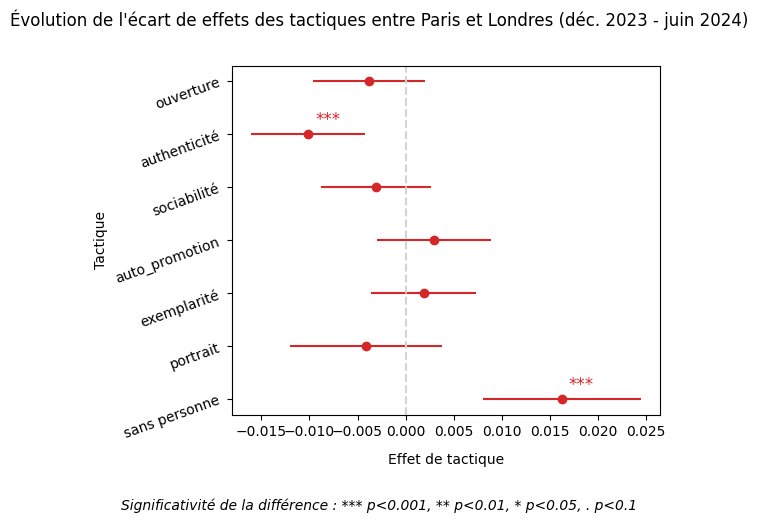

In [379]:
# # ---colors----
# blue_cmap = plt.cm.Blues
# orange_cmap = plt.cm.Oranges
# n = 2 # 每组柱子的数量
# london_colors = blue_cmap(np.linspace(0.3, 0.8, n))
# paris_colors  = orange_cmap(np.linspace(0.5, 0.8, n))

# ## ---layout 2facets----
# import matplotlib.gridspec as gridspec
# fig = plt.figure(figsize=(14, 5)) 
# gs = gridspec.GridSpec(1, 2, figure=fig, hspace=0.5, wspace=0.3)# 1行2列

# axes = []
# # 第一行两个：分别占两列宽 (0:2, 2:4, 4:6)
# ax1 = fig.add_subplot(gs[0, 0:1])
# ax2 = fig.add_subplot(gs[0, 1:2])#**
# axes.extend([ax1, ax2])


fig,ax=plt.subplots(figsize=(6,5))

df_plot=results_ddd_tactic.copy()
color_change="tab:red"


tactics=tactics_bio +['portrait', 'sans personne']

sub=df_plot[df_plot['label'].isin(tactics)].copy()

order = tactics[::-1]
sub["label"] = pd.Categorical(
    sub["label"],
    categories=order,
    ordered=True
)
sub = sub.sort_values("label")


ax.errorbar(
    x=sub["coef"],
    y=sub["label"],
    xerr=[sub["coef"] - sub["ci_low"], sub["ci_high"] - sub["coef"]],
    fmt='o', 
    color=color_change
)
# ---sig---
for _, row in sub.iterrows():
    ax.annotate(
        row["sig"],
        xy=(row["coef"], row["label"]),
        xytext=(5, 10), 
        textcoords='offset points',
        
        ha='left',
        va='center',
        fontsize=12,
        color=color_change
)    
        
ax.axvline(0, linestyle='--', color="lightgray", label="Changement de Londres")    
# ax.set_xlabel(f"{'Changement de niveau' if i==0 else 'Changement de porportion'}", labelpad=10)
ax.set_xlabel('Effet de tactique', labelpad=10)
ax.set_ylabel('Tactique')
ax.tick_params(axis='y', rotation=20)
# ax.set_title()



# # ## ---legend 2facets----
fig.suptitle(
    "Évolution de l'écart de effets des tactiques entre Paris et Londres (déc. 2023 - juin 2024)",
    fontsize=12,
    y=1.01
)
plt.figtext(
    0.5, 0.01,
    "Significativité de la différence : *** p<0.001, ** p<0.01, * p<0.05, . p<0.1",
    ha="center",
    fontsize=10,
    style="italic",   
)
plt.tight_layout(rect=[0, 0.1, 1, 1])# [left, bottom, right, top]
plt.subplots_adjust(bottom=0.2)#控制子图到底的距离，给text留出空间
plt.show()

## 文本策略大多不敏感？图片策略敏感
## authen效果下降更多

In [384]:
def get_real_cf_effect_data(model, tactics):
    results = []
    for var in tactics:
        print(var)        
        specs = [
            # london:
            ("2306", 0, var),
            ("2312", 0, f"{var} + C(time)[T.2312]:{var}"),
            ("2406", 0, f"{var} + C(time)[T.2406]:{var}"),
            
            # paris:
            ("2306", 1, f"{var} + in_paris:{var}"),
            
            ("2312", 1, f"""
                {var}
                + C(time)[T.2312]:{var}
                + in_paris:{var}
                + in_paris:C(time)[T.2312]:{var}
            """),
            
            ("2406", 1, f"""
                {var}
                + C(time)[T.2406]:{var}
                + in_paris:{var}
                + in_paris:C(time)[T.2406]:{var}
            """)        
        ]
    
        for time, paris, term in specs:
            test = model.t_test(term)
            # print(test)
            if time=="2406" and paris==1:
                ddd_term= f"""    
                in_paris:C(time)[T.2406]:{var}
                -in_paris:C(time)[T.2312]:{var}
                """
                ddd_test = model.t_test(ddd_term)
                print(f"ddd of var {var}:{ddd_test.effect[0]}\n")              
                effect_cf=test.effect[0]-ddd_test.effect[0]
            else :
                effect_cf=test.effect[0]
                    
            res={
            "time": time,
            "in_paris": paris,
            "variable":var,
            "effect_hat": test.effect[0],
            "effect_cf": effect_cf,
            "se": test.sd[0],
            "pval": test.pvalue,
            "sig":p_to_sig(test.pvalue),
            "ci_low": test.conf_int()[0][0],
            "ci_high": test.conf_int()[0][1],
            'label':f"{var_map.get(var,'') if var in var_map.keys() else var}"
            }
            results.append(res)
            
    df_results=pd.DataFrame(results)
    order = ["2306", "2312", "2406"]
    df_results["time"] = pd.Categorical(df_results["time"], categories=order, ordered=True)

    return df_results

tactics_effects=get_real_cf_effect_data(model=model_interaction, tactics=tactics_bio+tactics_pic_cat)

ouverture
ddd of var ouverture:-0.0037933983851114045

authenticité
ddd of var authenticité:-0.010128592202000433

sociabilité
ddd of var sociabilité:-0.003073705648097845

auto_promotion
ddd of var auto_promotion:0.0029296324016956157

exemplarité
ddd of var exemplarité:0.0018956947076475901

C(host_picture_type)[T.no_person]
ddd of var C(host_picture_type)[T.no_person]:0.01628397331248187

C(host_picture_type)[T.pro_style]
ddd of var C(host_picture_type)[T.pro_style]:-0.004110311131018052



In [385]:
tactics_effects[(tactics_effects['time']=='2406')&(tactics_effects['in_paris']==1)]

,time,in_paris,variable,effect_hat,effect_cf,se,pval,sig,ci_low,ci_high,label
5,2406,1,ouverture,-0.001756,0.002037,[0.0013665998638107627],0.198718851061418,,-0.004435,0.000922,ouverture
11,2406,1,authenticité,-0.000873,0.009256,[0.001410673074096899],0.5361320885646135,,-0.003638,0.001892,authenticité
17,2406,1,sociabilité,0.001823,0.004896,[0.001344942946684494],0.17536620839617312,,-0.000813,0.004459,sociabilité
23,2406,1,auto_promotion,-0.000408,-0.003338,[0.0014393320941209111],0.7766586331480403,,-0.003229,0.002413,auto_promotion
29,2406,1,exemplarité,-0.001056,-0.002952,[0.0012182240833406013],0.38601810228644184,,-0.003444,0.001332,exemplarité
35,2406,1,C(host_picture_type)[T.no_person],0.006079,-0.010205,[0.0018944567193281121],0.0013318725226930867,**,0.002366,0.009793,sans personne
41,2406,1,C(host_picture_type)[T.pro_style],0.003061,0.007171,[0.0016951895370272215],0.07099569394096006,.,-0.000262,0.006383,portrait


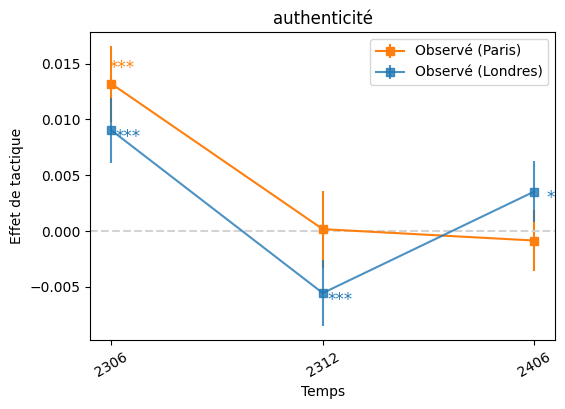

In [386]:
from utils import modeling_did
importlib.reload(modeling_did)
from utils.modeling_did import plot_one_real_cf_effect

plot_one_real_cf_effect(df_plot=tactics_effects, var="authenticité", cf=False)


0 ouverture
1 authenticité
2 sociabilité
3 auto_promotion
4 exemplarité


C:\Users\yeliu\AppData\Local\Temp\ipykernel_18128\636567652.py:57: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0.1, 1,1])


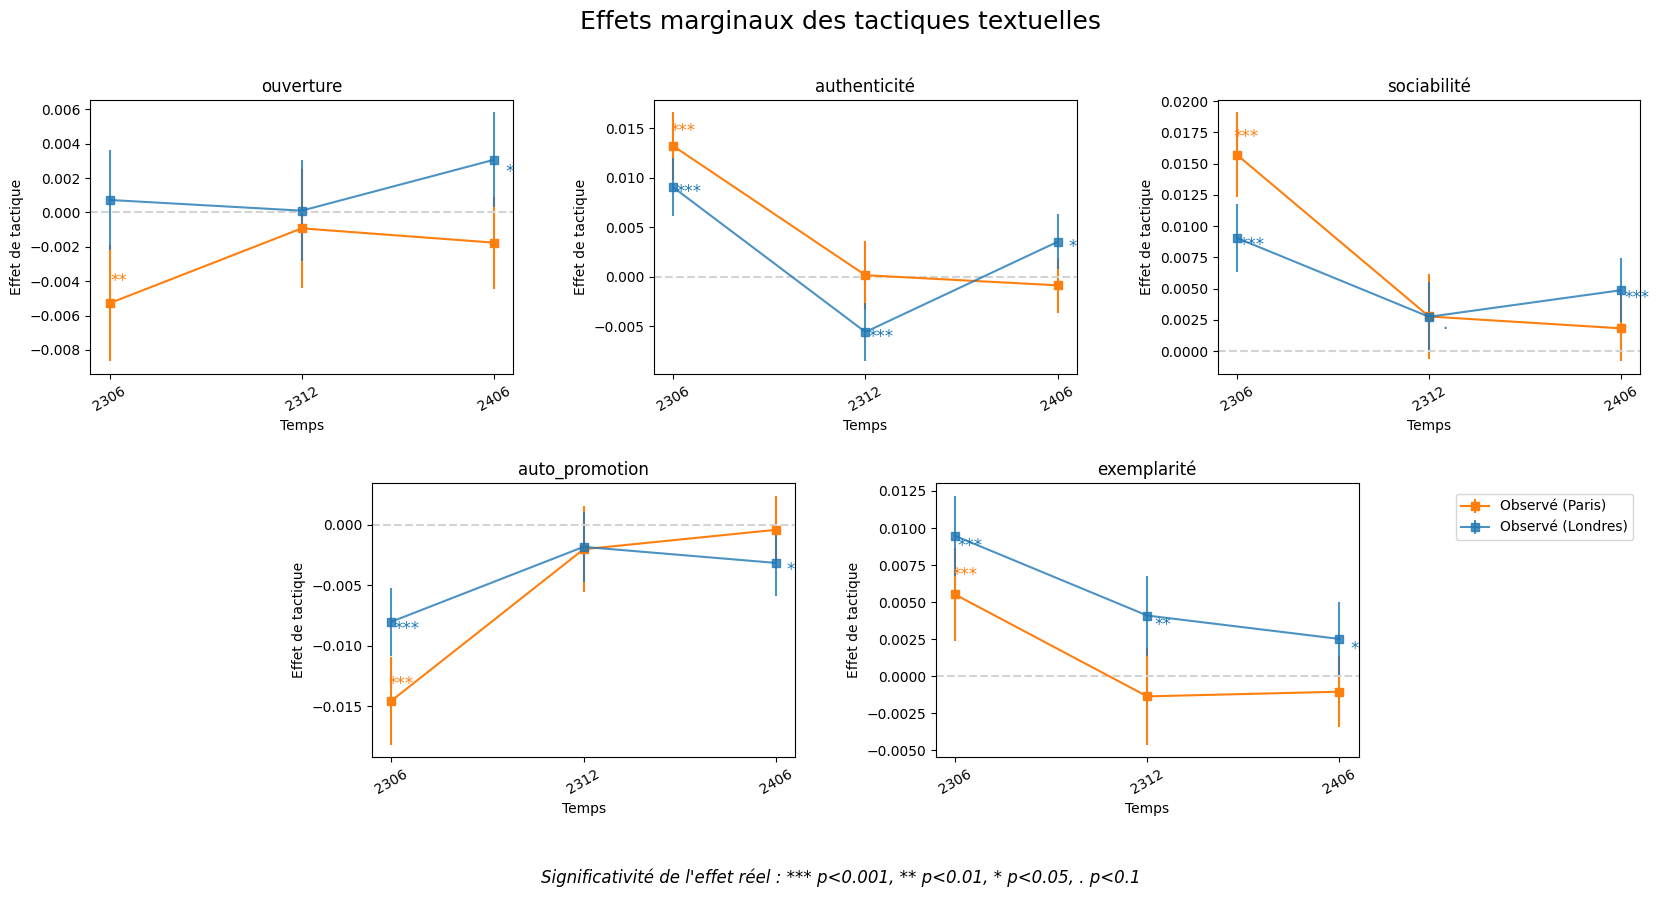

In [387]:
importlib.reload(modeling_did)
from utils.modeling_did import plot_one_real_cf_effect
import matplotlib.gridspec as gridspec

# -------------------layout-------------------
# 使用更细的列分辨率（2 行 × 6 列），方便把第二行两个图放在中间列
fig = plt.figure(figsize=(20,9))
gs = gridspec.GridSpec(2, 6, figure=fig, hspace=0.4, wspace=1)

axes = []
# # 第一行三个：分别占两列宽 (0:2, 2:4, 4:6)
ax1 = fig.add_subplot(gs[0, 0:2])
ax2 = fig.add_subplot(gs[0, 2:4])
ax3 = fig.add_subplot(gs[0, 4:6])
axes.extend([ax1, ax2, ax3])

# 第二行两个：让它们居中，分别占中间的两列 (1:3 和 3:5)
ax4 = fig.add_subplot(gs[1, 1:3])
ax5 = fig.add_subplot(gs[1, 3:5])
axes.extend([ax4, ax5])

# 确保 tactics_vars 长度为 5（或小于等于 len(axes)）
n_to_plot = min(len(tactics_bio), len(axes))

# --------------------------------------------

df_plot=tactics_effects.copy()
## plot
for i, var in enumerate(tactics_bio):
    print(i, var)
    plot_one_real_cf_effect(df_plot=df_plot, var=var, axes=axes, i=i, cf=False)

# --------------------legend------------------------
fig.suptitle(
        "Effets marginaux des tactiques textuelles",
        fontsize=18,
        y=0.98 #大标题到子图的距离, 越大越远
    )

from matplotlib.lines import Line2D
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(
    handles,
    labels,
    loc="upper right",
    bbox_to_anchor=(0.9,0.45) # legend (x, y)，x>1则在图外, y=0在底线
)

plt.figtext(
    0.5, 0.01,
    "Significativité de l'effet réel : *** p<0.001, ** p<0.01, * p<0.05, . p<0.1",
    ha="center",
    fontsize=12,
    style="italic"   
)

plt.tight_layout(rect=[0, 0.1, 1,1])
plt.subplots_adjust(bottom=0.15)#控制子图到底的距离，给text留出空间
plt.show()

# paris 2312-2406包括了时间变化+jo的ddd变化
##ouv，authen,soc下降，authen, exem提升，但是相对于london 2306都不显著？？



0 is_portrait
1 is_lifestyle
2 no_person


C:\Users\yeliu\AppData\Local\Temp\ipykernel_18128\1491663360.py:57: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0.1, 0.95,1])


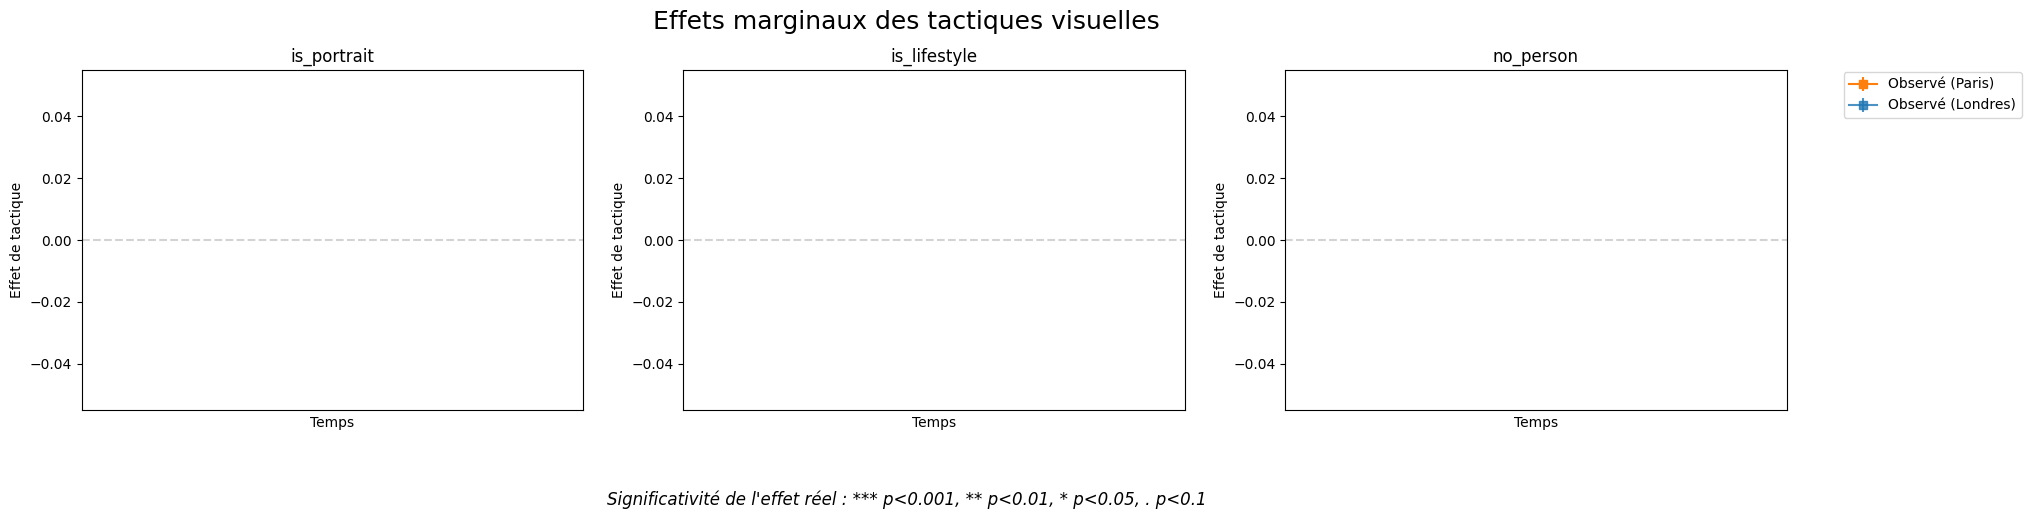

In [388]:
importlib.reload(modeling_did)
from utils.modeling_did import plot_one_real_cf_effect
import matplotlib.gridspec as gridspec


tactics=tactics_pic_dummies


# --------------------layout 3 facets-------------------
# 使用更细的列分辨率（2 行 × 6 列），方便把第二行两个图放在中间列
fig = plt.figure(figsize=(22,5))# sharey=True
gs = gridspec.GridSpec(1, 6, figure=fig, hspace=0.4, wspace=0.5)
axes = []
# 第一行三个：分别占两列宽 (0:2, 2:4, 4:6)
ax1 = fig.add_subplot(gs[0, 0:2])
ax2 = fig.add_subplot(gs[0, 2:4])
ax3 = fig.add_subplot(gs[0, 4:6])
axes.extend([ax1, ax2, ax3])


# --------------------------------------------

df_plot=tactics_effects.copy()

## plot
for i, var in enumerate(tactics):
    print(i, var)
    # lifestyle_2406p=df_plot[(df_plot['in_paris']==1)&(subdf['time']=="2406")&(df_plot['variable']=="is_lifestyle")]['effect_hat'].iloc[0]
    # print(var, lifestyle_2024p)
    plot_one_real_cf_effect(df_plot=df_plot, var=var, axes=axes, i=i, cf=False)
    

# --------------------legend------------------------
fig.suptitle(
        "Effets marginaux des tactiques visuelles",
        fontsize=18,
        y=1 #大标题到子图的距离, 越大越远
    )

from matplotlib.lines import Line2D
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(
    handles,
    labels,
    loc="upper right",
    bbox_to_anchor=(1.01,0.89) # legend (x, y)，x>1则在图外, y=0在底线
)

plt.figtext(
    0.5, 0.01,
    "Significativité de l'effet réel : *** p<0.001, ** p<0.01, * p<0.05, . p<0.1",
    ha="center",
    fontsize=12,
    style="italic"   
)

plt.tight_layout(rect=[0, 0.1, 0.95,1])
plt.subplots_adjust(bottom=0.2)#控制子图到底的距离，给text留出空间
plt.show()



## photo的效果全部下降！
### jo是对sp的效果的打击？


## subdf

In [8]:
df=df_all[(df_all['time']=="2406")&(df_all['in_paris']==1)].copy()

formula= ("booking_rate_l90d ~ C(host_identity_verified)  + review_scores_rating + has_rating +"
        "number_of_reviews_ltm + "
        "C(host_is_superhost) +"
        "years_since_host + professional_host + "
        "host_response_rate +  C(host_response_time)+"
        "has_text + lang_en + lang_fr + text_length+"
        "price  + availability_90 + C(room_type) + C(instant_bookable) + "
        "ouverture + authenticité + sociabilité + auto_promotion + exemplarité+"
        "C(host_picture_type)"
)

model_sub=smf.ols(formula, data=df).fit()
summary=model_sub.summary()
print(summary)

                            OLS Regression Results                            
Dep. Variable:      booking_rate_l90d   R-squared:                       0.350
Model:                            OLS   Adj. R-squared:                  0.349
Method:                 Least Squares   F-statistic:                     1162.
Date:                Fri, 24 Apr 2026   Prob (F-statistic):               0.00
Time:                        09:16:15   Log-Likelihood:                 39092.
No. Observations:               62738   AIC:                        -7.812e+04
Df Residuals:                   62708   BIC:                        -7.785e+04
Df Model:                          29                                         
Covariance Type:            nonrobust                                         
                                                  coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------------------

In [11]:
tactics_pic_cat=["C(host_picture_type)[T.pro_style]","C(host_picture_type)[T.no_person]"]

model=model_sub

tactics=tactics_bio+tactics_pic_cat
coef=model.params[tactics]
se=model.bse[tactics]
pval=model.pvalues[tactics]
results=[]
time="2406"
in_paris=1
res=pd.DataFrame({
    'time':time,
    "in_paris":in_paris,
    'variable':tactics,
    'coef':coef,
    'se':se,
    'pval':pval
})
results.append(res)
results_df=pd.concat(results, axis=0)

results_df=results_df.reset_index(drop=True)
results_df['sig']=results_df['pval'].apply(p_to_sig)
display(results_df)

,time,in_paris,variable,coef,se,pval,sig
0,2406,1,ouverture,-0.003366,0.001076,1.766269e-03,**
1,2406,1,authenticité,0.002602,0.001112,1.935930e-02,*
2,2406,1,sociabilité,0.004565,0.001026,8.562325e-06,***
3,2406,1,auto_promotion,-0.006597,0.001188,2.835222e-08,***
4,2406,1,exemplarité,0.001418,0.000922,1.240435e-01,
5,2406,1,C(host_picture_type)[T.pro_style],0.003923,0.001271,2.028729e-03,**
6,2406,1,C(host_picture_type)[T.no_person],-0.003843,0.001522,1.157879e-02,*


In [446]:
tactics=tactics_bio+tactics_pic_cat
results=[]

i=0
for p in df_all['in_paris'].unique():
    for t in df_all['time'].unique():
        print(f"in_paris={p}, time={t}")
        df=df_all[(df_all['in_paris']==p)&(df_all['time']==t)].copy()
        print(df[['in_paris','time']].value_counts(dropna=False))
        formula= ("booking_rate_l90d ~ C(host_identity_verified)  + review_scores_rating + has_rating +"
                "number_of_reviews_ltm + "
                "C(host_is_superhost) +"
                "years_since_host + professional_host + "
                "host_response_rate +  C(host_response_time)+"
                "has_text + lang_en + lang_fr + text_length+"
                "price  + availability_90 + C(room_type) + C(instant_bookable) + "
                # "in_paris+C(time)+"
                "ouverture + authenticité + sociabilité + auto_promotion + exemplarité+"
                "C(host_picture_type)"
        )
        model_sub=smf.ols(formula, data=df).fit()
        if i ==0:
            print(model_sub.summary())
        # ---data---
        coef=model_sub.params[tactics]
        se=model_sub.bse[tactics]
        pval=model_sub.pvalues[tactics]
        labels=[var_map.get(var,'') if var in var_map.keys() else var for var in tactics]
        res=pd.DataFrame({
            'time':t,
            "in_paris":p,
            'variable':tactics,
            'coef':coef.values,
            'se':se.values,
            'pval':pval.values,
            "ci_low": (coef - 1.96 * se).values,
            "ci_high": (coef + 1.96 * se).values,
            'label':labels
        })
        
        results.append(res)
        i+=0
        # break
results_df=pd.concat(results, axis=0)
results_df=results_df.reset_index(drop=True)
results_df['sig']=results_df['pval'].apply(p_to_sig)
tactics_effects_sepa=results_df.copy()
display(tactics_effects_sepa)
    

in_paris=0, time=2306
in_paris  time
0         2306    42356
Name: count, dtype: int64
                            OLS Regression Results                            
Dep. Variable:      booking_rate_l90d   R-squared:                       0.441
Model:                            OLS   Adj. R-squared:                  0.441
Method:                 Least Squares   F-statistic:                     1151.
Date:                Thu, 23 Apr 2026   Prob (F-statistic):               0.00
Time:                        18:15:54   Log-Likelihood:                 8002.4
No. Observations:               42356   AIC:                        -1.594e+04
Df Residuals:                   42326   BIC:                        -1.569e+04
Df Model:                          29                                         
Covariance Type:            nonrobust                                         
                                                  coef    std err          t      P>|t|      [0.025      0.975]
-----------

,time,in_paris,variable,coef,se,pval,ci_low,ci_high,label,sig
0,2306,0,ouverture,-0.000827,0.001711,6.287276e-01,-0.004180,0.002526,ouverture,
1,2306,0,authenticité,0.005319,0.001753,2.409652e-03,0.001883,0.008754,authenticité,**
2,2306,0,sociabilité,0.009638,0.001629,3.349743e-09,0.006444,0.012832,sociabilité,***
3,2306,0,auto_promotion,-0.007121,0.001796,7.350288e-05,-0.010641,-0.003601,auto_promotion,***
4,2306,0,exemplarité,0.008508,0.001615,1.390057e-07,0.005342,0.011674,exemplarité,***
5,2306,0,C(host_picture_type)[T.no_person],-0.013235,0.002609,3.935652e-07,-0.018348,-0.008121,C(host_picture_type)[T.no_person],***
6,2306,0,C(host_picture_type)[T.pro_style],0.000408,0.002420,8.659524e-01,-0.004334,0.005151,C(host_picture_type)[T.pro_style],
7,2312,0,ouverture,0.001577,0.001186,1.835962e-01,-0.000747,0.003901,ouverture,
8,2312,0,authenticité,-0.001839,0.001218,1.310909e-01,-0.004226,0.000548,authenticité,
9,2312,0,sociabilité,0.003440,0.001136,2.460069e-03,0.001214,0.005667,sociabilité,**


In [395]:
tactics_effects_sepa[(tactics_effects_sepa['time']=='2406')&(tactics_effects['in_paris']==1)]

,time,in_paris,variable,coef,se,pval,ci_low,ci_high,label,sig
15,2406,0,authenticité,0.001989,0.001343,0.138492,-0.000643,0.004621,authenticité,
16,2406,0,sociabilité,0.003311,0.001255,0.008355,0.000851,0.005772,sociabilité,**
17,2406,0,auto_promotion,-0.001295,0.001402,0.355391,-0.004043,0.001452,auto_promotion,
35,2406,1,ouverture,-0.003366,0.001076,0.001766,-0.005476,-0.001256,ouverture,**
39,2406,1,exemplarité,0.001418,0.000922,0.124044,-0.000389,0.003226,exemplarité,
40,2406,1,C(host_picture_type)[T.no_person],-0.003843,0.001522,0.011579,-0.006825,-0.000860,sans personne,*
41,2406,1,C(host_picture_type)[T.pro_style],0.003923,0.001271,0.002029,0.001432,0.006415,portrait,**


,time,in_paris,variable,coef,se,pval,ci_low,ci_high,label,sig
1,2306,0,authenticité,0.005319,0.001753,0.002410,0.001883,0.008754,authenticité,**
8,2312,0,authenticité,-0.001839,0.001218,0.131091,-0.004226,0.000548,authenticité,
15,2406,0,authenticité,0.001989,0.001343,0.138492,-0.000643,0.004621,authenticité,
22,2306,1,authenticité,0.004792,0.002396,0.045548,0.000095,0.009489,authenticité,*
29,2312,1,authenticité,0.002922,0.001924,0.128835,-0.000849,0.006693,authenticité,
36,2406,1,authenticité,0.002602,0.001112,0.019359,0.000421,0.004782,authenticité,*


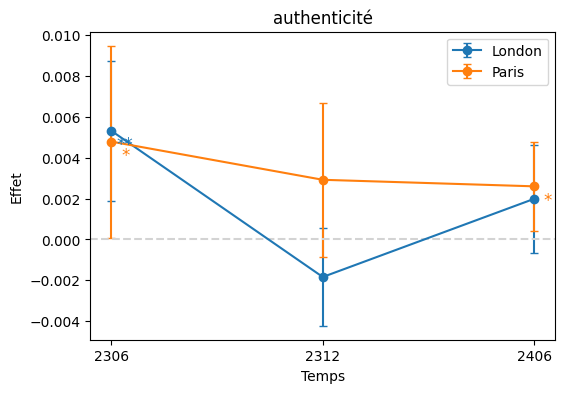

In [396]:
df_plot=tactics_effects_sepa.copy()

var='authenticité'
sub=df_plot[df_plot['variable']==var]
display(sub)

fig, ax = plt.subplots(figsize=(6,4))

for p in sub["in_paris"].unique():
    g = sub[sub["in_paris"] == p]
    ax.errorbar(
        x=g["time"],
        y=g["coef"],
        yerr=1.96 * g["se"],   # 或直接 ci_low/high
        marker="o",
        linestyle="-",
        capsize=3,
        label=f"{'Paris' if p==1 else 'London'}"
    )
    for _, row in g.iterrows():
        if row['sig'] != "":
            ax.annotate(
                row['sig'],
                xy=(row['time'], row['coef']),
                xytext=(10, -10),
                textcoords='offset points',
                ha='center',
                va='center',
                fontsize=12,
                color='tab:blue' if row['in_paris']==0 else 'tab:orange'
            )
               
# ---layout---
ax.set_xlabel("Temps")
ax.set_ylabel("Effet")
ax.set_title(f"{var}")
ax.axhline(0, color="lightgray", linestyle='--')
ax.legend()

0 ouverture
1 authenticité
2 sociabilité
3 auto_promotion
4 exemplarité


C:\Users\yeliu\AppData\Local\Temp\ipykernel_18128\3533095284.py:89: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0.1, 1,1])


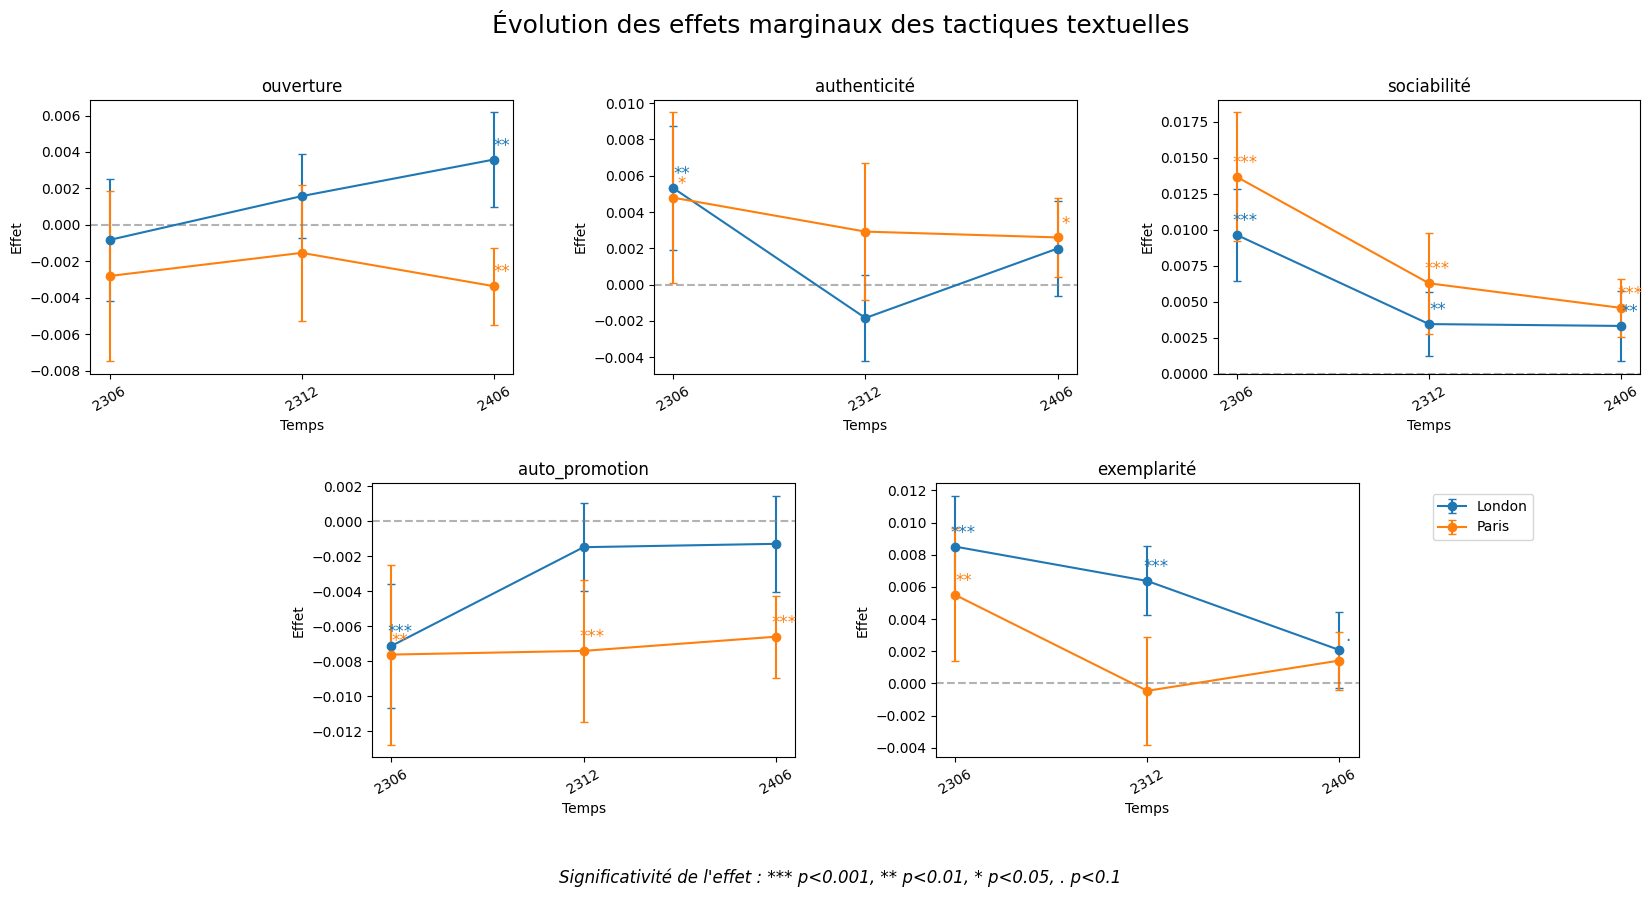

In [402]:
df_plot=tactics_effects_sepa.copy()
tactics=tactics_bio

# ---layout 5facets---
# 使用更细的列分辨率（2 行 × 6 列），方便把第二行两个图放在中间列
fig = plt.figure(figsize=(20,9))
gs = gridspec.GridSpec(2, 6, figure=fig, hspace=0.4, wspace=1)

axes = []
# # 第一行三个：分别占两列宽 (0:2, 2:4, 4:6)
ax1 = fig.add_subplot(gs[0, 0:2])
ax2 = fig.add_subplot(gs[0, 2:4])
ax3 = fig.add_subplot(gs[0, 4:6])
axes.extend([ax1, ax2, ax3])

# 第二行两个：让它们居中，分别占中间的两列 (1:3 和 3:5)
ax4 = fig.add_subplot(gs[1, 1:3])
ax5 = fig.add_subplot(gs[1, 3:5])
axes.extend([ax4, ax5])

# 确保 tactics_vars 长度为 5（或小于等于 len(axes)）
n_to_plot = min(len(tactics), len(axes))

# ---plot---
for i, var in enumerate(tactics):
    ax=axes[i]
    
    print(i,var)
    sub=df_plot[df_plot['label']==var]
    # display(sub)
    
    for p in sub["in_paris"].unique():
        g = sub[sub["in_paris"] == p]
        ax.errorbar(
            x=g["time"],
            y=g["coef"],
            yerr=1.96 * g["se"],   # 或直接 ci_low/high
            marker="o",
            linestyle="-",
            capsize=3,
            label=f"{'Paris' if p==1 else 'London'}",
        )
        for _, row in g.iterrows():
            if row['sig'] != "":
                ax.annotate(
                    row['sig'],
                    xy=(row['time'], row['coef']),
                    xytext=(6, 10),
                    textcoords='offset points',
                    ha='center',
                    va='center',
                    fontsize=12,
                    color='tab:blue' if row['in_paris']==0 else 'tab:orange'
                )
            
    # ---layout---
    ax.set_xlabel("Temps")
    ax.tick_params(axis="x", rotation=30)
    ax.set_ylabel("Effet")
    ax.set_title(f"{var}")
    ax.axhline(0, color="gray", alpha=0.6, linestyle='--')
    
    # break

# --------------------legend------------------------
fig.suptitle(
        "Évolution des effets marginaux des tactiques textuelles",
        fontsize=18,
        y=0.98 #大标题到子图的距离, 越大越远
    )

from matplotlib.lines import Line2D
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(
    handles,
    labels,
    loc="upper right",
    bbox_to_anchor=(0.85,0.45) # legend (x, y)，x>1则在图外, y=0在底线
)

plt.figtext(
    0.5, 0.01,
    "Significativité de l'effet : *** p<0.001, ** p<0.01, * p<0.05, . p<0.1",
    ha="center",
    fontsize=12,
    style="italic"   
)

plt.tight_layout(rect=[0, 0.1, 1,1])
plt.subplots_adjust(bottom=0.15)#控制子图到底的距离，给text留出空间
plt.show()

# paris 2312-2406包括了时间变化+jo的ddd变化
##ouv，authen,soc下降，authen, exem提升，但是相对于london 2306都不显著？？



0 portrait


,time,in_paris,variable,coef,se,pval,ci_low,ci_high,label,sig
6,2306,0,C(host_picture_type)[T.pro_style],0.000408,0.002420,0.865952,-0.004334,0.005151,portrait,
13,2312,0,C(host_picture_type)[T.pro_style],-0.000815,0.001645,0.620247,-0.004039,0.002409,portrait,
20,2406,0,C(host_picture_type)[T.pro_style],0.003173,0.001841,0.084713,-0.000434,0.006781,portrait,.
27,2306,1,C(host_picture_type)[T.pro_style],0.002756,0.003048,0.365909,-0.003218,0.008730,portrait,
34,2312,1,C(host_picture_type)[T.pro_style],0.005158,0.002305,0.025262,0.000640,0.009676,portrait,*
41,2406,1,C(host_picture_type)[T.pro_style],0.003923,0.001271,0.002029,0.001432,0.006415,portrait,**


1 sans personne


,time,in_paris,variable,coef,se,pval,ci_low,ci_high,label,sig
5,2306,0,C(host_picture_type)[T.no_person],-0.013235,0.002609,3.935652e-07,-0.018348,-0.008121,sans personne,***
12,2312,0,C(host_picture_type)[T.no_person],-0.003278,0.001779,6.534963e-02,-0.006765,0.000208,sans personne,.
19,2406,0,C(host_picture_type)[T.no_person],-0.003793,0.001968,5.391905e-02,-0.007649,0.000064,sans personne,.
26,2306,1,C(host_picture_type)[T.no_person],-0.021212,0.003592,3.567639e-09,-0.028253,-0.014171,sans personne,***
33,2312,1,C(host_picture_type)[T.no_person],-0.003811,0.002681,1.551974e-01,-0.009067,0.001444,sans personne,
40,2406,1,C(host_picture_type)[T.no_person],-0.003843,0.001522,1.157879e-02,-0.006825,-0.000860,sans personne,*


C:\Users\yeliu\AppData\Local\Temp\ipykernel_18128\1291472901.py:83: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0.2, 1,1])


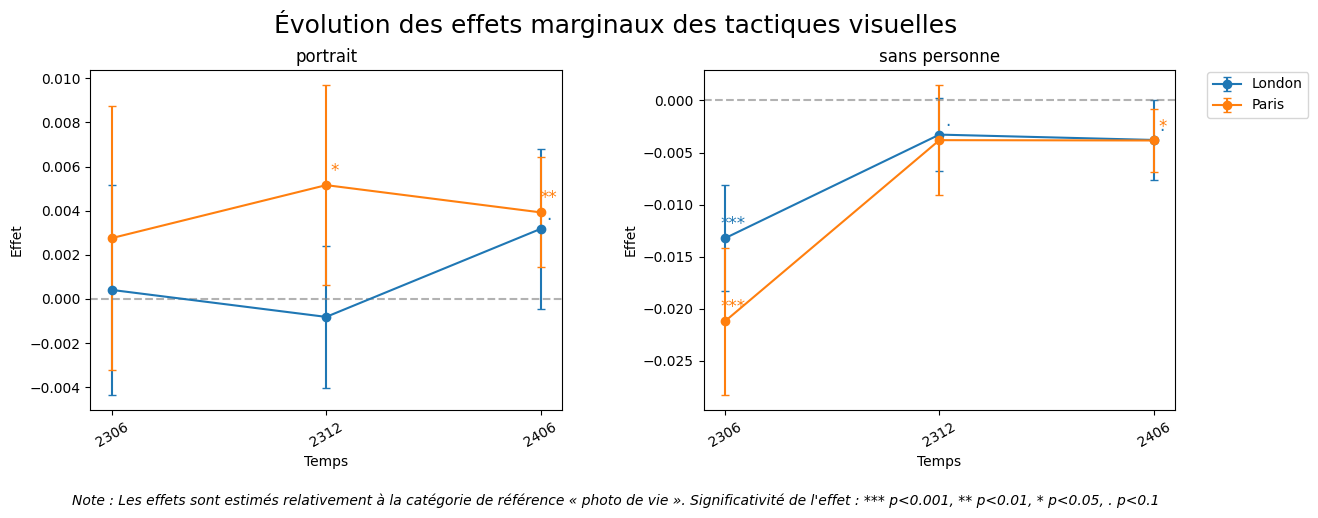

In [411]:
## ---layout 2facets----
import matplotlib.gridspec as gridspec
fig = plt.figure(figsize=(14, 5)) 
gs = gridspec.GridSpec(1, 2, figure=fig, hspace=0.5, wspace=0.3)# 1行2列

axes = []
# 第一行两个：分别占两列宽 (0:2, 2:4, 4:6)
ax1 = fig.add_subplot(gs[0, 0:1])
ax2 = fig.add_subplot(gs[0, 1:2])#**
axes.extend([ax1, ax2])


# ---plot---
df_plot=tactics_effects_sepa.copy()
tactics=['portrait','sans personne']

for i, var in enumerate(tactics):
    ax=axes[i]
    
    print(i,var)
    sub=df_plot[df_plot['label']==var]
    display(sub)
    
    for p in sub["in_paris"].unique():
        g = sub[sub["in_paris"] == p]
        ax.errorbar(
            x=g["time"],
            y=g["coef"],
            yerr=1.96 * g["se"],   # 或直接 ci_low/high
            marker="o",
            linestyle="-",
            capsize=3,
            label=f"{'Paris' if p==1 else 'London'}",
        )
        for _, row in g.iterrows():
            if row['sig'] != "":
                ax.annotate(
                    row['sig'],
                    xy=(row['time'], row['coef']),
                    xytext=(6, 10),
                    textcoords='offset points',
                    ha='center',
                    va='center',
                    fontsize=12,
                    color='tab:blue' if row['in_paris']==0 else 'tab:orange'
                )
            
    # ---layout---
    ax.set_xlabel("Temps")
    ax.tick_params(axis="x", rotation=30)
    ax.set_ylabel("Effet")
    
    ax.set_title(var)
    ax.axhline(0, color="gray", alpha=0.6, linestyle='--')
    
    # break

# --------------------legend------------------------
fig.suptitle(
        "Évolution des effets marginaux des tactiques visuelles",
        fontsize=18,
        y=1 #大标题到子图的距离, 越大越远
    )

from matplotlib.lines import Line2D
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(
    handles,
    labels,
    loc="upper right",
    bbox_to_anchor=(1,0.89) # legend (x, y)，x>1则在图外, y=0在底线
)

plt.figtext(
    0.5, 0.01,
    f"Note : Les effets sont estimés relativement à la catégorie de référence « photo de vie ». "
    f"Significativité de l'effet : *** p<0.001, ** p<0.01, * p<0.05, . p<0.1",
    ha="center",
    fontsize=10,
    style="italic"   
)

plt.tight_layout(rect=[0, 0.2, 1,1])
plt.subplots_adjust(bottom=0.2)#控制子图到底的距离，给text留出空间
plt.show()
## 均下降，但是portrait下降最多，sans personne下降最少

## new old bookingrate

In [434]:
df=df_all.copy()
agg=df.groupby(['time','in_paris','is_new_host'])['booking_rate_l90d'].mean().reset_index(name="mean")
agg

,time,in_paris,is_new_host,mean
0,2306,0,0,0.162585
1,2306,1,0,0.213811
2,2312,0,0,0.069228
3,2312,0,1,0.080679
4,2312,1,0,0.093164
5,2312,1,1,0.123016
6,2406,0,0,0.113584
7,2406,0,1,0.138104
8,2406,1,0,0.085889
9,2406,1,1,0.064405


C:\Users\yeliu\AppData\Local\Temp\ipykernel_18128\3361451394.py:54: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0.1, 1, 1])# [left, bottom, right, top]


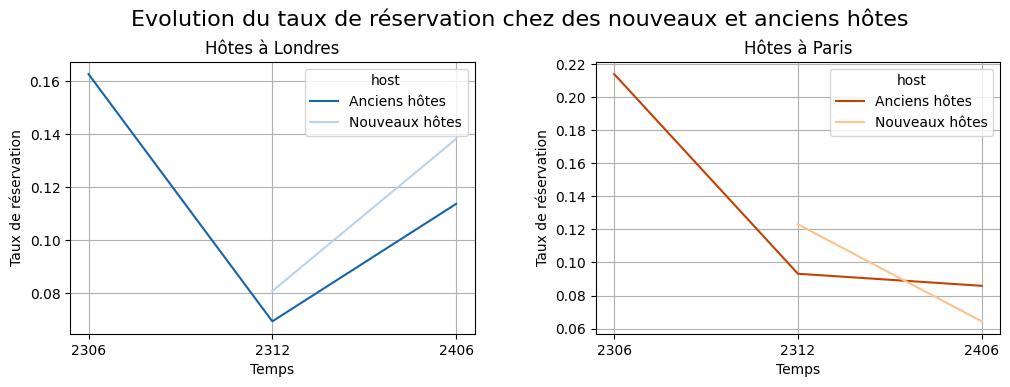

In [436]:

## ---layout 2facets----
import matplotlib.gridspec as gridspec
fig = plt.figure(figsize=(12, 4)) 
gs = gridspec.GridSpec(1, 2, figure=fig, hspace=0.5, wspace=0.3)# 1行2列

axes = []
# 第一行两个：分别占两列宽 (0:2, 2:4, 4:6)
ax1 = fig.add_subplot(gs[0, 0:1])
ax2 = fig.add_subplot(gs[0, 1:2], sharex=ax1)#**
axes.extend([ax1, ax2])


# ---colors----
blue_cmap = plt.cm.Blues
orange_cmap = plt.cm.Oranges
n = 2 # ==len(hue) 每组柱子的数量
london_colors = blue_cmap(np.linspace(0.3, 0.8, n))
paris_colors  = orange_cmap(np.linspace(0.3, 0.8, n))


for i, p in enumerate(agg['in_paris'].unique()):
    ax=axes[i]
    sub=agg[agg['in_paris']==p].copy()
    sub["host"] = sub["is_new_host"].map({
        0: "Anciens hôtes",
        1: "Nouveaux hôtes"
    })
    colors=paris_colors if p==1 else london_colors

    sns.lineplot(
        data=sub,
        x="time",
        y="mean",
        hue="host",
        palette={
            "Anciens hôtes": colors[1],
            "Nouveaux hôtes": colors[0]
        },
        ax=ax
    )
    ax.grid()
    ax.set_title(f"Hôtes à {'Paris' if p==1 else 'Londres'}")
    ax.set_ylabel("Taux de réservation")
    ax.set_xlabel('Temps')
    
    
## ---legend 2facets----
fig.suptitle(
   'Evolution du taux de réservation chez des nouveaux et anciens hôtes',
    fontsize=16,
    y=1.01
)

plt.tight_layout(rect=[0, 0.1, 1, 1])# [left, bottom, right, top]
plt.subplots_adjust(bottom=0.2)#控制子图到底的距离，给text留出空间
plt.show()




## tactics_effect_new

In [456]:
df_all['is_new_host'].value_counts()

is_new_host
0    204510
1     62342
Name: count, dtype: int64

In [457]:
tactics=tactics_bio+tactics_pic_cat
results=[]

for p in df_all['in_paris'].unique():
    for t in df_all['time'].unique():
        print(f"in_paris={p}, time={t}")
        df=df_all[(df_all['in_paris']==p)&(df_all['time']==t)].copy()
        if t=="2306":
            formula= ("booking_rate_l90d ~ C(host_identity_verified)  + review_scores_rating + has_rating +"
                    "number_of_reviews_ltm + "
                    "C(host_is_superhost) +"
                    "years_since_host + professional_host + "
                    "host_response_rate +  C(host_response_time)+"
                    "has_text + lang_en + lang_fr + text_length+"
                    "price  + availability_90 + C(room_type) + C(instant_bookable) + "
                    "ouverture + authenticité + sociabilité + auto_promotion + exemplarité+C(host_picture_type)"
            )
        else :
            formula= ("booking_rate_l90d ~ C(host_identity_verified)  + review_scores_rating + has_rating +"
                    "number_of_reviews_ltm + "
                    "C(host_is_superhost) +"
                    "years_since_host + professional_host + "
                    "host_response_rate +  C(host_response_time)+"
                    "has_text + lang_en + lang_fr + text_length+"
                    "price  + availability_90 + C(room_type) + C(instant_bookable) + "
                    "is_new_host*(ouverture + authenticité + sociabilité + auto_promotion + exemplarité+C(host_picture_type))"
            )            
        model_sub=smf.ols(formula, data=df).fit()
        print(model_sub.summary())
        
        # ---data---
        coef=model_sub.params[tactics]
        se=model_sub.bse[tactics]
        pval=model_sub.pvalues[tactics]
        var_map={
            "C(host_picture_type)[T.no_person]":"sans personne",
            "C(host_picture_type)[T.pro_style]":"portrait"
        }
        labels=[var_map.get(var,'') if var in var_map.keys() else var for var in tactics]
        res=pd.DataFrame({
            'time':t,
            "in_paris":p,
            'variable':tactics,
            'coef':coef.values,
            'se':se.values,
            'pval':pval.values,
            "ci_low": (coef - 1.96 * se).values,
            "ci_high": (coef + 1.96 * se).values,
            'label':labels
        })
        results.append(res)
        break
results_df=pd.concat(results, axis=0)
results_df=results_df.reset_index(drop=True)
results_df['sig']=results_df['pval'].apply(p_to_sig)
tactics_effects_new=results_df.copy()
display(tactics_effects_new)

in_paris=0, time=2306
                            OLS Regression Results                            
Dep. Variable:      booking_rate_l90d   R-squared:                       0.441
Model:                            OLS   Adj. R-squared:                  0.441
Method:                 Least Squares   F-statistic:                     1151.
Date:                Thu, 23 Apr 2026   Prob (F-statistic):               0.00
Time:                        18:21:59   Log-Likelihood:                 8002.4
No. Observations:               42356   AIC:                        -1.594e+04
Df Residuals:                   42326   BIC:                        -1.569e+04
Df Model:                          29                                         
Covariance Type:            nonrobust                                         
                                                  coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------

,time,in_paris,variable,coef,se,pval,ci_low,ci_high,label,sig
0,2306,0,ouverture,-0.000827,0.001711,6.287276e-01,-0.004180,0.002526,ouverture,
1,2306,0,authenticité,0.005319,0.001753,2.409652e-03,0.001883,0.008754,authenticité,**
2,2306,0,sociabilité,0.009638,0.001629,3.349743e-09,0.006444,0.012832,sociabilité,***
3,2306,0,auto_promotion,-0.007121,0.001796,7.350288e-05,-0.010641,-0.003601,auto_promotion,***
4,2306,0,exemplarité,0.008508,0.001615,1.390057e-07,0.005342,0.011674,exemplarité,***
5,2306,0,C(host_picture_type)[T.no_person],-0.013235,0.002609,3.935652e-07,-0.018348,-0.008121,sans personne,***
6,2306,0,C(host_picture_type)[T.pro_style],0.000408,0.002420,8.659524e-01,-0.004334,0.005151,portrait,
7,2306,1,ouverture,-0.002806,0.002389,2.401568e-01,-0.007488,0.001876,ouverture,
8,2306,1,authenticité,0.004792,0.002396,4.554798e-02,0.000095,0.009489,authenticité,*
9,2306,1,sociabilité,0.013674,0.002290,2.377683e-09,0.009186,0.018162,sociabilité,***


In [451]:
tactics_effects_new[(tactics_effects_new['time']=="2406")&(tactics_effects_new["in_paris"]==1)]

,time,in_paris,variable,coef,se,pval,ci_low,ci_high,label,sig
35,2406,1,ouverture,-0.003651,0.001323,0.005776,-0.006244,-0.001059,ouverture,**
36,2406,1,authenticité,0.001864,0.001399,0.182719,-0.000878,0.004606,authenticité,
37,2406,1,sociabilité,0.003860,0.001283,0.002625,0.001345,0.006374,sociabilité,**
38,2406,1,auto_promotion,-0.006717,0.001459,0.000004,-0.009576,-0.003858,auto_promotion,***
39,2406,1,exemplarité,0.001304,0.001178,0.268190,-0.001004,0.003613,exemplarité,
40,2406,1,C(host_picture_type)[T.no_person],-0.009702,0.001996,0.000001,-0.013614,-0.005789,sans personne,***
41,2406,1,C(host_picture_type)[T.pro_style],0.004742,0.001803,0.008550,0.001207,0.008276,portrait,**
